## Tổng quan nội dung notebook

Notebook này trình bày một pipeline **text classification end-to-end** cho bài tập lớn, được tổ chức theo các bước sau:

1. **Setup & Configuration**: mount Drive, khai báo thư viện, cấu hình tham số và thiết lập seed để tái lập thí nghiệm.
2. **EDA & Data Processing**: làm sạch dữ liệu, thống kê chất lượng dữ liệu, phân phối lớp và phân tích độ dài văn bản.
3. **Data Split & Metrics**: chia train/validation/test theo stratified split và định nghĩa bộ chỉ số đánh giá.
4. **Model Training**:
   - Baseline truyền thống: TF-IDF + SVM.
   - Neural word-level: BiLSTM, BiGRU.
   - Transformer: BERT-base, DistilBERT.
   - So sánh chiến lược fine-tuning cho DistilBERT (freeze backbone vs layerwise LR).
5. **Evaluation & Comparison**: tổng hợp bảng metric, learning curves và biểu đồ so sánh trực quan giữa các mô hình.
6. **Model Analysis**: error analysis, calibration (ECE + reliability diagram), robustness dưới nhiễu văn bản, interpretability.
7. **Efficiency & Ensemble**: so sánh số tham số/latency và thử nghiệm ensemble xác suất.
8. **Artifact & Demo**: lưu model/metrics và dựng phần demo suy luận để sử dụng mô hình đã huấn luyện.

Mục tiêu cuối cùng là không chỉ so sánh độ chính xác, mà còn phân tích độ tin cậy, độ bền và khả năng triển khai thực tế của từng mô hình.



## Mô tả dataset

- **Nguồn dữ liệu**: file `Context.csv` (đọc từ Google Drive).
- **Kích thước dữ liệu** (theo output hiện tại): khoảng **31,380 mẫu**.
- **Số cột chính**:
  - `Text`: nội dung văn bản đầu vào.
  - `Context/Topic`: nhãn chủ đề/ngữ cảnh.
- **Số lớp**: **11 lớp** phân loại.
- **Chất lượng dữ liệu sau làm sạch**:
  - Loại bỏ văn bản rỗng sau chuẩn hóa khoảng trắng.
  - Số mẫu trùng lặp thấp (khoảng vài chục mẫu theo output EDA chi tiết).
- **Chia tập dữ liệu**:
  - Train/Validation/Test theo **stratified split** để giữ phân phối nhãn ổn định.
  - Kích thước thực nghiệm đã chạy: **25,072 / 3,134 / 3,135**.

Bài toán đặt ra là phân loại mỗi câu văn bản vào đúng một lớp `Context/Topic` trong 11 nhãn.



###Khai báo thư viện và configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<!-- report-comment:mount_drive -->

#### Phân tích Cell: Mount Drive
- Chức năng cell: Kết nối Google Drive để đọc dữ liệu và lưu artifacts xuyên suốt toàn bộ pipeline.
- Output chính: Drive đã mount thành công, sẵn sàng truy cập đường dẫn `/content/drive`.
- Nhận xét từ output: Đây là điều kiện bắt buộc để chạy end-to-end trong Colab; việc mount ổn định giúp tái lập thí nghiệm và lưu checkpoint/metrics nhất quán.


In [ ]:
import os
import re
import json
import math
import time
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional, Callable

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)



In [ ]:
@dataclass
class Config:
    seed: int = 42

    # Data
    data_path: Optional[str] = None
    artifact_dir: str = "/content/drive/MyDrive/deep_learning/artifacts"
    test_size: float = 0.10
    val_size: float = 0.10

    # Text
    max_len: int = 256

    # Batching
    batch_size_word: int = 64
    batch_size_hf: int = 16

    # Training budget
    epochs_word: int = 16
    epochs_hf: int = 10
    patience: int = 2

    # Optimization
    lr_word: float = 1e-3
    lr_hf: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.06

    # Model names
    bert_name: str = "bert-base-uncased"
    distil_name: str = "distilbert-base-uncased"

    # Vocab (kept for compatibility)
    min_freq: int = 2
    max_vocab_size: int = 40000

    # Extension toggles
    run_calibration: bool = True
    run_robustness: bool = True
    run_efficiency: bool = True
    run_ensemble: bool = True

CFG = Config()
os.makedirs(CFG.artifact_dir, exist_ok=True)

# Data path auto-discovery
candidate_paths = [
    CFG.data_path,
    "Context.csv",
    "../Context.csv",
    "/content/drive/MyDrive/deep_learning/data/Context.csv",
    "/content/drive/MyDrive/Deep Learning/data/Context.csv",
]
CFG.data_path = next((p for p in candidate_paths if p and os.path.exists(p)), None)
if CFG.data_path is None:
    raise FileNotFoundError("Khong tim thay Context.csv. Hay cap nhat CFG.data_path.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("vram_gb:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

print("data_path:", CFG.data_path)

# Shared BERT tokenizer/vocab used across ALL pipelines
BERT_TOKENIZER = AutoTokenizer.from_pretrained(CFG.bert_name, use_fast=True)
PAD_TOKEN = BERT_TOKENIZER.pad_token or "[PAD]"
UNK_TOKEN = BERT_TOKENIZER.unk_token or "[UNK]"
PAD_ID = int(BERT_TOKENIZER.pad_token_id if BERT_TOKENIZER.pad_token_id is not None else 0)
UNK_ID = int(BERT_TOKENIZER.unk_token_id if BERT_TOKENIZER.unk_token_id is not None else 100)


def bert_tokenize(text: str) -> List[str]:
    return BERT_TOKENIZER.tokenize(str(text))


def bert_encode_ids(text: str, max_len: int) -> List[int]:
    ids = BERT_TOKENIZER.encode(
        str(text),
        add_special_tokens=False,
        truncation=True,
        max_length=max_len,
    )
    return ids if len(ids) > 0 else [UNK_ID]


def bert_pretokenize_text(text: str) -> str:
    return " ".join(bert_tokenize(text))


print("shared_tokenizer:", CFG.bert_name)
print("shared_vocab_size:", int(BERT_TOKENIZER.vocab_size))
print("pad_token/pad_id:", PAD_TOKEN, PAD_ID)
print("unk_token/unk_id:", UNK_TOKEN, UNK_ID)


device: cuda
gpu: Tesla T4
vram_gb: 14.56
data_path: /content/drive/MyDrive/deep_learning/data/Context.csv


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

shared_tokenizer: bert-base-uncased
shared_vocab_size: 30522
pad_token/pad_id: [PAD] 0
unk_token/unk_id: [UNK] 100


<!-- report-comment:config_env -->

#### Phân tích Cell: Cấu hình và môi trường
- Chức năng cell: Khởi tạo toàn bộ tham số thí nghiệm (seed, split, batch size, epoch, learning rate, model names) và thiết lập thiết bị chạy.
- Output chính: Hệ thống nhận `device: cuda`.
- Nhận xét từ output: Có GPU giúp thời gian huấn luyện Transformer khả thi cho bài tập lớn. Việc gom cấu hình vào `Config` giúp pipeline dễ kiểm soát và tái sử dụng khi so sánh nhiều mô hình.


In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)


###Phân tích và Xử lý dữ liệu (EDA)

In [ ]:
def load_and_clean_data(path: str) -> Tuple[pd.DataFrame, Dict[str, int], Dict[int, str]]:
    df = pd.read_csv(path)
    required_cols = {"Text", "Context/Topic"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Thiáº¿u cá»™t: {missing}")

    for col in ["Text", "Context/Topic"]:
        df[col] = df[col].astype(str)

    df["Text"] = df["Text"].str.replace(r"\s+", " ", regex=True).str.strip()
    df["Context/Topic"] = df["Context/Topic"].str.strip()
    df = df[df["Text"].str.len() > 0].reset_index(drop=True)

    labels = sorted(df["Context/Topic"].unique().tolist())
    label2id = {lab: i for i, lab in enumerate(labels)}
    id2label = {i: lab for lab, i in label2id.items()}

    df["label"] = df["Context/Topic"].map(label2id)
    assert df["label"].isna().sum() == 0
    return df, label2id, id2label


df, label2id, id2label = load_and_clean_data(CFG.data_path)
num_labels = len(label2id)
print("shape:", df.shape)
print("num_labels:", num_labels)
print("labels:", list(label2id.keys()))


shape: (31380, 3)
num_labels: 11
labels: ['Animals', 'Compliment', 'Education', 'Health', 'Heavy Emotion', 'Joke', 'Love', 'Politics', 'Religion', 'Science', 'Self']


<!-- report-comment:load_clean -->

#### Phân tích Cell: Nạp dữ liệu và làm sạch
- Chức năng cell: Đọc `Context.csv`, kiểm tra cột bắt buộc, chuẩn hóa text và mã hóa nhãn.
- Output chính: Dữ liệu sau làm sạch có `shape: (31380, 3)`.
- Nhận xét từ output: Quy mô dữ liệu đủ lớn để so sánh nhiều họ mô hình. Bước chuẩn hóa đầu vào giúp giảm nhiễu kỹ thuật trước khi EDA và huấn luyện.


n_samples: 31380
Context/Topic
Heavy Emotion    3674
Religion         3463
Love             3229
Self             3103
Compliment       3061
Animals          2622
Health           2594
Education        2534
Joke             2476
Science          2428
Politics         2196


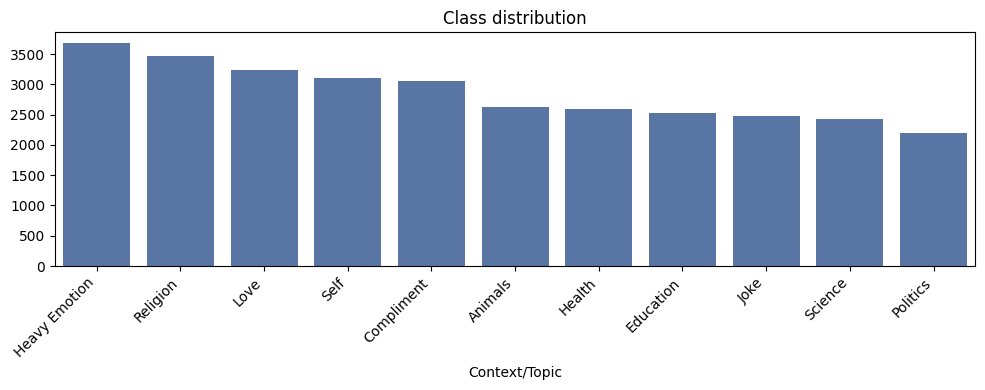

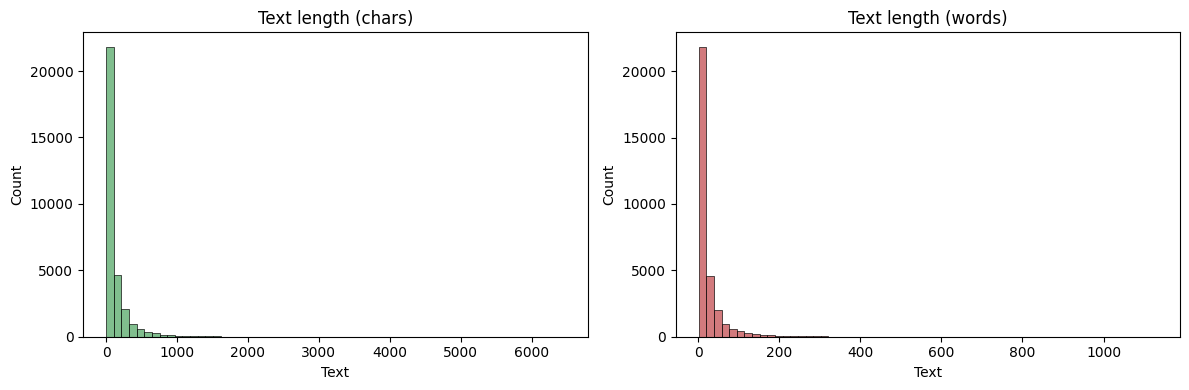

In [ ]:
# Quick EDA
print("n_samples:", len(df))
class_counts = df["Context/Topic"].value_counts().sort_values(ascending=False)
print(class_counts.to_string())

char_lens = df["Text"].str.len()
word_lens = df["Text"].str.split().str.len()

plt.figure(figsize=(10, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(char_lens, bins=60, ax=axes[0], color="#55A868")
axes[0].set_title("Text length (chars)")
sns.histplot(word_lens, bins=60, ax=axes[1], color="#C44E52")
axes[1].set_title("Text length (words)")
plt.tight_layout()
plt.show()


<!-- report-comment:quick_eda -->

#### Phân tích Cell: Quick EDA
- Chức năng cell: Thống kê nhanh số mẫu, phân phối lớp và phân bố độ dài văn bản.
- Output chính: `n_samples = 31,380` kèm biểu đồ class distribution và histogram độ dài.
- Nhận xét từ output: Cell này xác nhận dữ liệu đa lớp với quy mô lớn và độ dài văn bản biến thiên, tạo cơ sở hợp lý để thử cả mô hình truyền thống lẫn mô hình ngữ cảnh sâu.


n_samples=31,380 | n_classes=11 | duplicates=39 | empty_text_after_clean=0


,count,percent,imbalance_vs_min
Context/Topic,,,
Heavy Emotion,3674,11.71,1.67
Religion,3463,11.04,1.58
Love,3229,10.29,1.47
Self,3103,9.89,1.41
Compliment,3061,9.75,1.39
Animals,2622,8.36,1.19
Health,2594,8.27,1.18
Education,2534,8.08,1.15
Joke,2476,7.89,1.13


char_len                          word_len                    \
                  mean median     std min   max     mean median    std min   
Context/Topic                                                                
Animals          56.25   43.0   55.86   2   799    10.26    8.0  10.74   1   
Compliment       86.23   55.0   94.16   1   852    16.38   11.0  17.94   1   
Education       127.57   60.0  188.31   1  4374    22.59   10.0  34.82   1   
Health           93.72   61.0  122.50   1  2875    15.70   10.0  22.60   1   
Heavy Emotion   211.89   75.0  363.59   1  5835    41.13   15.0  70.99   1   
Joke            232.93  108.0  387.38   1  6461    43.63   20.0  72.22   1   
Love            193.40   79.0  311.47   1  4822    37.88   16.0  60.64   1   
Politics         84.67   71.0   52.51   3   427    13.58   11.0   8.69   1   
Religion        134.19   73.0  169.76   1  2069    23.68   12.0  30.32   1   
Science          92.97   67.0   78.90   3  1205    14.55   10.0  12.48   1   
Self            105.43   61.0  156.68   1  3049    19.89   12.0  29.80   1   

                     
                max  
Context/Topic        
Animals         162  
Compliment      159  
Education       815  
Health          547  
Heavy Emotion  1132  
Joke           1106  
Love            900  
Politics         76  
Religion        374  
Science         194  
Self            570

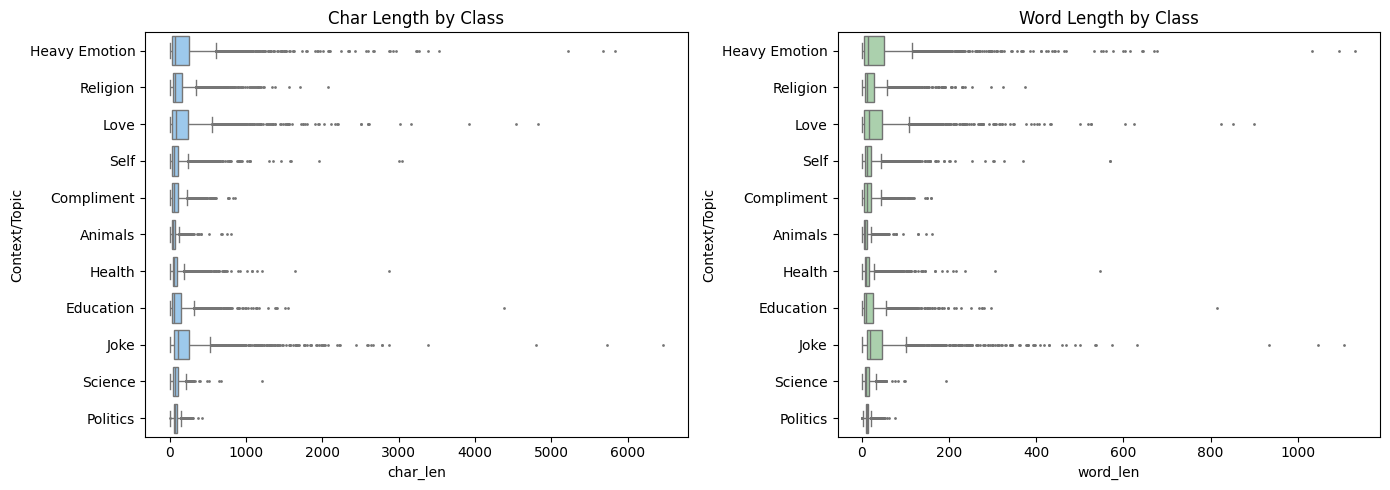

Top unigrams:


,token,count
0,i,30821
1,the,24992
2,to,21587
3,and,20655
4,a,19041
5,of,12817
6,in,11156
7,s,10824
8,it,9758
9,you,9738


Top bigrams:


,token,count
0,i m,4114
1,and i,2322
2,don t,2296
3,in the,2113
4,it s,1954
5,of the,1787
6,i am,1491
7,i was,1437
8,i have,1407
9,i don,1288


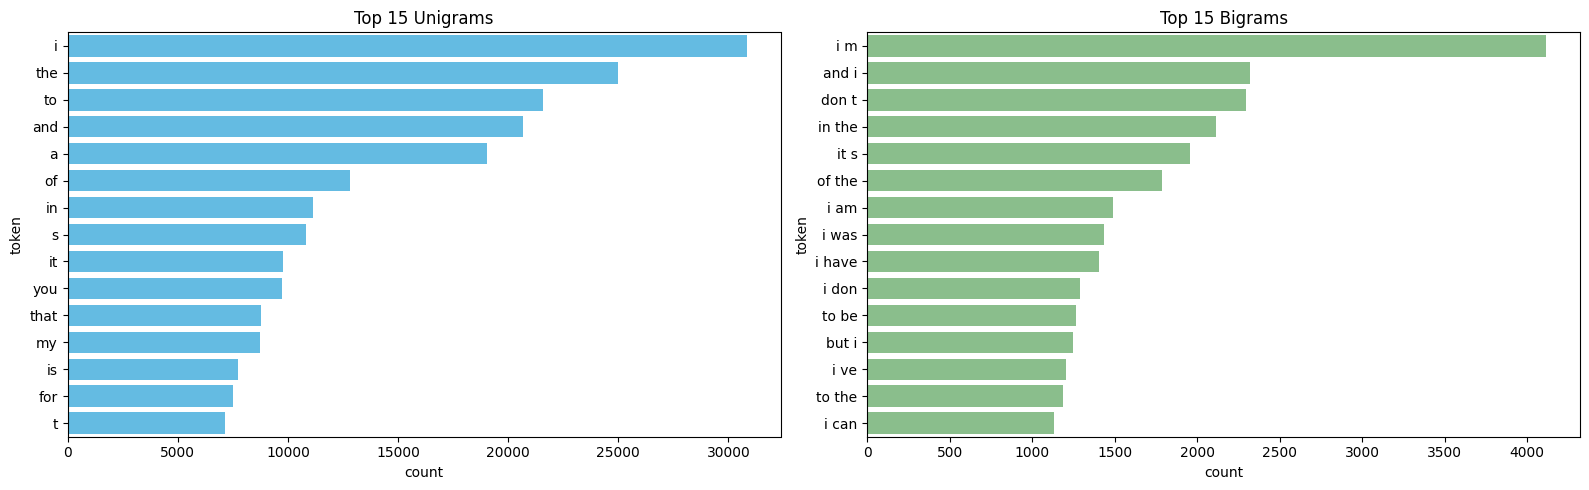

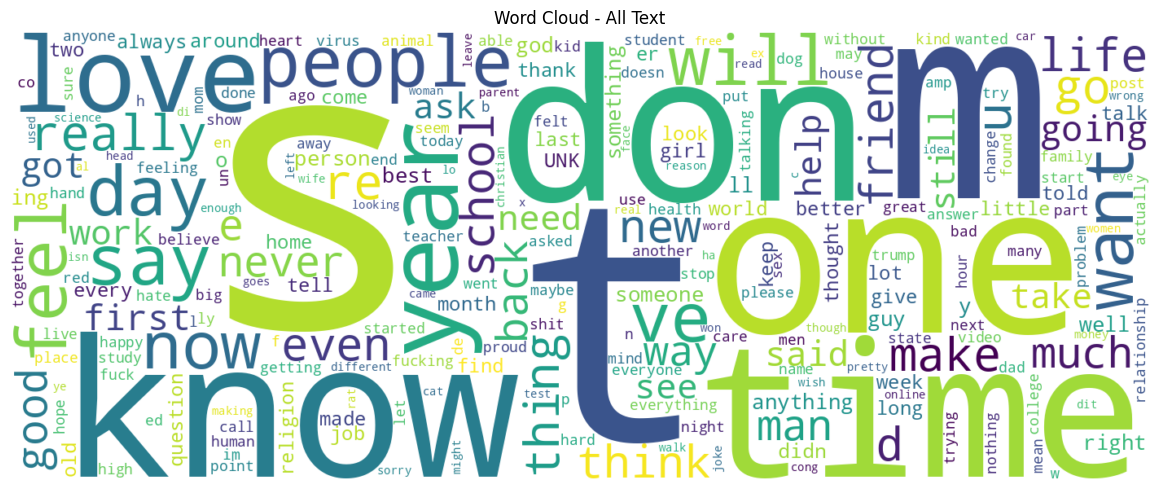

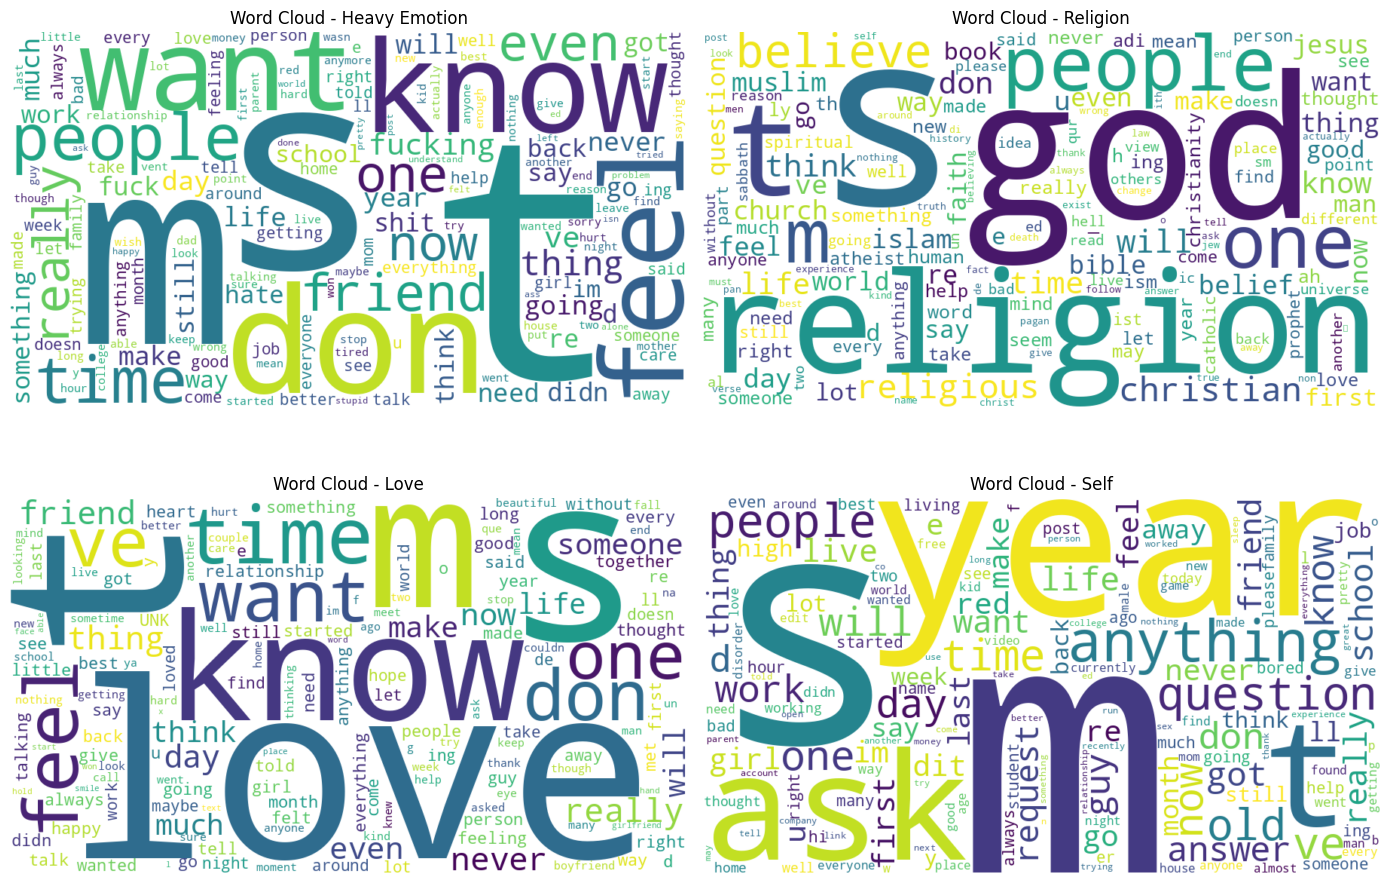

In [ ]:
# Detailed EDA
from sklearn.feature_extraction.text import CountVectorizer
from transformers import logging as hf_logging

# Basic data quality
n_samples = len(df)
n_classes = df["Context/Topic"].nunique()
dup_rows = int(df.duplicated(subset=["Text", "Context/Topic"]).sum())
empty_after_clean = int((df["Text"].str.strip().str.len() == 0).sum())

print(f"n_samples={n_samples:,} | n_classes={n_classes} | duplicates={dup_rows} | empty_text_after_clean={empty_after_clean}")

class_counts_detail = df["Context/Topic"].value_counts().sort_values(ascending=False)
class_pct = (100.0 * class_counts_detail / class_counts_detail.sum()).round(2)
class_table = pd.DataFrame({
    "count": class_counts_detail,
    "percent": class_pct,
})
class_table["imbalance_vs_min"] = (class_table["count"] / class_table["count"].min()).round(2)
display(class_table)

# Length statistics by class
eda_df = df.copy()
eda_df["char_len"] = eda_df["Text"].str.len()
eda_df["word_len"] = eda_df["Text"].str.split().str.len()

len_stats = (
    eda_df.groupby("Context/Topic")[["char_len", "word_len"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
display(len_stats)

# Box plots for text length by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = class_counts_detail.index.tolist()

sns.boxplot(data=eda_df, y="Context/Topic", x="char_len", order=order, orient="h", ax=axes[0], color="#90CAF9", fliersize=1)
axes[0].set_title("Char Length by Class")

sns.boxplot(data=eda_df, y="Context/Topic", x="word_len", order=order, orient="h", ax=axes[1], color="#A5D6A7", fliersize=1)
axes[1].set_title("Word Length by Class")

plt.tight_layout()
plt.show()

# Build BERT-pretokenized text for token-level EDA (suppress max-length warnings for EDA only)
_prev_verbosity = hf_logging.get_verbosity()
hf_logging.set_verbosity_error()
pretokenized_texts = df["Text"].map(bert_pretokenize_text).tolist()
hf_logging.set_verbosity(_prev_verbosity)

# Top n-grams
def top_ngrams(texts: List[str], ngram_range=(1, 1), top_k: int = 25):
    vec = CountVectorizer(
        lowercase=False,
        token_pattern=r"(?u)\b\S+\b",
        ngram_range=ngram_range,
        min_df=2,
    )
    try:
        X = vec.fit_transform(texts)
    except ValueError:
        return pd.DataFrame(columns=["token", "count"])

    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.asarray(vec.get_feature_names_out())

    if len(vocab) == 0:
        return pd.DataFrame(columns=["token", "count"])

    idx = np.argsort(-freqs)[:top_k]
    return pd.DataFrame({"token": vocab[idx], "count": freqs[idx].astype(int)})


top_uni = top_ngrams(pretokenized_texts, ngram_range=(1, 1), top_k=25)
top_bi = top_ngrams(pretokenized_texts, ngram_range=(2, 2), top_k=25)

print("Top unigrams:")
display(top_uni)
print("Top bigrams:")
display(top_bi)

if len(top_uni) > 0 and len(top_bi) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=top_uni.head(15), y="token", x="count", ax=axes[0], color="#4FC3F7")
    axes[0].set_title("Top 15 Unigrams")

    sns.barplot(data=top_bi.head(15), y="token", x="count", ax=axes[1], color="#81C784")
    axes[1].set_title("Top 15 Bigrams")

    plt.tight_layout()
    plt.show()
else:
    print("Skip n-gram bar plot because extracted vocabulary is empty.")

# Word cloud (overall + per class)
try:
    from wordcloud import WordCloud, STOPWORDS
    wc_stopwords = set(STOPWORDS)
    wc_stopwords.update({"[cls]", "[sep]", "[pad]", "##"})

    all_text = " ".join(pretokenized_texts)
    wc_all = WordCloud(
        width=1400,
        height=550,
        background_color="white",
        max_words=250,
        collocations=False,
        stopwords=wc_stopwords,
    ).generate(all_text)

    plt.figure(figsize=(14, 5))
    plt.imshow(wc_all, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - All Text")
    plt.tight_layout()
    plt.show()

    top_classes = class_counts_detail.head(4).index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for i, cls in enumerate(top_classes):
        cls_text = " ".join(eda_df.loc[eda_df["Context/Topic"] == cls, "Text"].map(bert_pretokenize_text).tolist())
        wc_cls = WordCloud(
            width=900,
            height=500,
            background_color="white",
            max_words=160,
            collocations=False,
            stopwords=wc_stopwords,
        ).generate(cls_text)

        axes[i].imshow(wc_cls, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(f"Word Cloud - {cls}")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("WordCloud is unavailable. Install with: !pip -q install wordcloud")
    print("detail:", e)


<!-- report-comment:detailed_eda -->

#### Phân tích Cell: Detailed EDA
- Chức năng cell: Phân tích chất lượng dữ liệu sâu hơn (trùng lặp, text rỗng, cân bằng lớp, đặc trưng token).
- Output chính: `duplicates = 39`, `empty_text_after_clean = 0`, bảng tỷ lệ lớp và biểu đồ bổ sung.
- Nhận xét từ output: Dữ liệu nhìn chung sạch, ít trùng lặp và không có văn bản rỗng sau làm sạch. Đây là điều kiện tốt để kết quả so sánh mô hình phản ánh năng lực mô hình hơn là lỗi dữ liệu.


In [ ]:
df = df.drop_duplicates(subset=['Text', 'Context/Topic']).reset_index(drop=True)

###Chia tập dữ liệu

In [ ]:
def stratified_split(df: pd.DataFrame, test_size: float, val_size: float, seed: int):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=seed,
        stratify=df["Context/Topic"],
    )
    val_frac_of_train = val_size / (1.0 - test_size)
    train_df, val_df = train_test_split(
        train_df,
        test_size=val_frac_of_train,
        random_state=seed,
        stratify=train_df["Context/Topic"],
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )

train_df, val_df, test_df = stratified_split(df, CFG.test_size, CFG.val_size, CFG.seed)
print("train/val/test:", len(train_df), len(val_df), len(test_df))


train/val/test: 25072 3134 3135


<!-- report-comment:split -->

#### Phân tích Cell: Chia tập dữ liệu và metric cơ bản
- Chức năng cell: Chia train/val/test theo stratified split và định nghĩa metric đánh giá.
- Output chính: Kích thước tập: `train/val/test = 25072 / 3134 / 3135`.
- Nhận xét từ output: Tỷ lệ chia ổn định, đủ dữ liệu cho huấn luyện và đánh giá tổng quát. Stratified split giúp giảm sai lệch phân phối nhãn giữa các tập.


In [ ]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro")),
    }


def compute_extended_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    base = compute_metrics(y_true, y_pred)
    ext = {
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }
    return {**base, **ext}


def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, id2label: Dict[int, str], title: str, normalize: bool = True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)

    labels = [id2label[i] for i in range(len(id2label))]
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", square=True, cbar=True)
    plt.title(title + (" (normalized)" if normalize else ""))
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.tight_layout()
    plt.show()


###Huấn luyện các mô hình

#### Baseline - TF-IDF + SVM


baseline val: {'accuracy': 0.6604977664326739, 'macro_f1': 0.6678509698713856, 'micro_f1': 0.6604977664326739}
baseline test: {'accuracy': 0.6755980861244019, 'macro_f1': 0.6825526576924074, 'micro_f1': 0.6755980861244019}
               precision    recall  f1-score   support

      Animals       0.73      0.70      0.71       262
   Compliment       0.77      0.73      0.75       305
    Education       0.71      0.65      0.68       253
       Health       0.63      0.68      0.65       259
Heavy Emotion       0.55      0.66      0.60       367
         Joke       0.78      0.68      0.73       247
         Love       0.68      0.66      0.67       323
     Politics       0.86      0.80      0.83       220
     Religion       0.68      0.66      0.67       346
      Science       0.55      0.63      0.59       243
         Self       0.63      0.62      0.63       310

     accuracy                           0.68      3135
    macro avg       0.69      0.68      0.68      3135
 weig

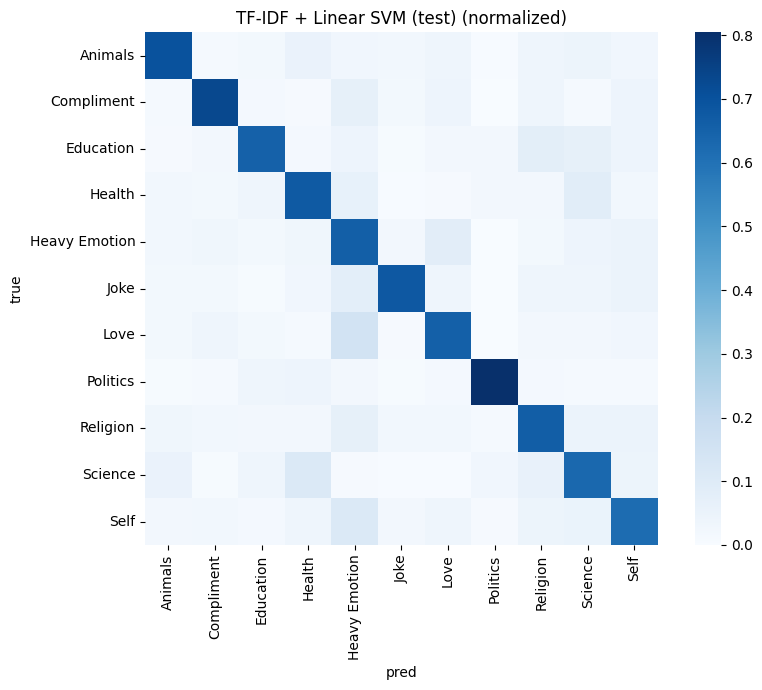

In [ ]:
def train_baseline_tfidf_svm(train_df, val_df, test_df):
    vectorizer = TfidfVectorizer(lowercase=True, max_features=50000, ngram_range=(1, 2))

    X_train = vectorizer.fit_transform(train_df["Text"].tolist())
    y_train = train_df["label"].values

    X_val = vectorizer.transform(val_df["Text"].tolist())
    y_val = val_df["label"].values

    X_test = vectorizer.transform(test_df["Text"].tolist())
    y_test = test_df["label"].values

    clf = SVC(kernel="linear", probability=True, random_state=CFG.seed)
    clf.fit(X_train, y_train)

    val_pred = clf.predict(X_val)
    val_prob = clf.predict_proba(X_val)

    test_pred = clf.predict(X_test)
    test_prob = clf.predict_proba(X_test)

    return {
        "name": "tfidf_svm",
        "family": "sklearn",
        "vectorizer": vectorizer,
        "model": clf,
        "history": None,
        "val": {
            "y_true": y_val,
            "y_pred": val_pred,
            "y_prob": val_prob,
            "metrics": compute_metrics(y_val, val_pred),
        },
        "test": {
            "y_true": y_test,
            "y_pred": test_pred,
            "y_prob": test_prob,
            "metrics": compute_metrics(y_test, test_pred),
        },
    }

baseline_artifact = train_baseline_tfidf_svm(train_df, val_df, test_df)
print("baseline val:", baseline_artifact["val"]["metrics"])
print("baseline test:", baseline_artifact["test"]["metrics"])
print(classification_report(
    baseline_artifact["test"]["y_true"],
    baseline_artifact["test"]["y_pred"],
    target_names=[id2label[i] for i in range(num_labels)],
))
plot_confusion(
    baseline_artifact["test"]["y_true"],
    baseline_artifact["test"]["y_pred"],
    id2label,
    "TF-IDF + Linear SVM (test)",
)


<!-- report-comment:baseline -->

#### Phân tích Cell: Baseline TF-IDF + SVM
- Chức năng cell: Huấn luyện baseline truyền thống làm mốc tham chiếu cho toàn bộ bài toán.
- Output chính: Test `accuracy = 0.6756`, `macro_f1 = 0.6826`.
- Nhận xét từ output: Baseline đạt chất lượng khá tốt, chứng minh đặc trưng n-gram vẫn mạnh trên dữ liệu này. Đây là mốc quan trọng để đánh giá lợi ích thực sự của các mô hình neural phức tạp hơn.


#### Nhóm mô hình Neural network (BiLSTM / BiGRU)


In [ ]:
# Word-level pipeline now uses SHARED BERT tokenizer + BERT vocab IDs.
PAD_TOKEN = BERT_TOKENIZER.pad_token or "[PAD]"
UNK_TOKEN = BERT_TOKENIZER.unk_token or "[UNK]"


def simple_tokenize(text: str) -> List[str]:
    return bert_tokenize(text)


def build_vocab(texts: List[str], min_freq: int = 2, max_size: int = 40000) -> Dict[str, int]:
    # Keep signature for compatibility; return full BERT vocab mapping.
    vocab = BERT_TOKENIZER.get_vocab()
    return {tok: int(idx) for tok, idx in vocab.items()}


def numericalize(tokens: List[str], vocab: Dict[str, int]) -> List[int]:
    ids = BERT_TOKENIZER.convert_tokens_to_ids(tokens)
    unk = int(vocab.get(UNK_TOKEN, UNK_ID))
    return [int(i if i is not None else unk) for i in ids]


def word_dropout(tokens: List[str], p: float, rng: np.random.Generator) -> List[str]:
    if p <= 0:
        return tokens
    keep = rng.random(len(tokens)) > p
    out = [t for t, k in zip(tokens, keep) if k]
    return out if len(out) > 0 else tokens[:1]


class WordDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, vocab: Dict[str, int], max_len: int, augment: bool = False, dropout_p: float = 0.1, seed: int = 42):
        self.texts = frame["Text"].tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.vocab = vocab
        self.max_len = max_len
        self.augment = augment
        self.dropout_p = dropout_p
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx: int):
        tokens = simple_tokenize(self.texts[idx])
        if self.augment:
            tokens = word_dropout(tokens, self.dropout_p, self.rng)
        ids = numericalize(tokens, self.vocab)[: self.max_len]
        if len(ids) == 0:
            ids = [int(self.vocab.get(UNK_TOKEN, UNK_ID))]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


def collate_word(batch, pad_id: int, max_len: int):
    seqs, ys = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    max_batch_len = min(int(lengths.max()), max_len)
    padded = torch.full((len(seqs), max_batch_len), fill_value=pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        s = s[:max_batch_len]
        padded[i, : len(s)] = s
    return padded, lengths.clamp(max=max_len), torch.stack(list(ys))


vocab = build_vocab(train_df["Text"].tolist(), min_freq=CFG.min_freq, max_size=CFG.max_vocab_size)
print("vocab_size (shared BERT):", len(vocab))

train_ds_word = WordDataset(train_df, vocab, max_len=CFG.max_len, augment=True, dropout_p=0.10, seed=CFG.seed)
val_ds_word = WordDataset(val_df, vocab, max_len=CFG.max_len, augment=False, seed=CFG.seed)
test_ds_word = WordDataset(test_df, vocab, max_len=CFG.max_len, augment=False, seed=CFG.seed)

pad_id = int(vocab.get(PAD_TOKEN, PAD_ID))
train_loader_word = DataLoader(train_ds_word, batch_size=CFG.batch_size_word, shuffle=True, collate_fn=lambda b: collate_word(b, pad_id, CFG.max_len))
val_loader_word = DataLoader(val_ds_word, batch_size=CFG.batch_size_word, shuffle=False, collate_fn=lambda b: collate_word(b, pad_id, CFG.max_len))
test_loader_word = DataLoader(test_ds_word, batch_size=CFG.batch_size_word, shuffle=False, collate_fn=lambda b: collate_word(b, pad_id, CFG.max_len))


vocab_size (shared BERT): 30522


<!-- report-comment:word_pipeline -->

#### Phân tích Cell: Pipeline word-level cho BiLSTM/BiGRU
- Chức năng cell: Xây dựng DataLoader cho mô hình RNN và đồng bộ tokenizer/vocab.
- Output chính: `vocab_size (shared BERT) = 30522`.
- Nhận xét từ output: Dùng chung vocab với BERT giúp so sánh công bằng hơn giữa RNN và Transformer, giảm sai khác do biểu diễn đầu vào.


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, emb_dim: int = 200, hidden_dim: int = 256, num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = self.dropout(torch.cat([fw, bw], dim=1))
        return self.fc(h)


class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, emb_dim: int = 200, hidden_dim: int = 256, num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.gru(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = self.dropout(torch.cat([fw, bw], dim=1))
        return self.fc(h)


def make_padding_mask(input_ids: torch.Tensor, pad_id: int = 0) -> torch.Tensor:
    return input_ids.eq(pad_id)


class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, d_model: int = 256, nhead: int = 8, num_layers: int = 4, dim_feedforward: int = 1024, dropout: float = 0.1, max_len: int = 512, pad_id: int = 0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.max_len = max_len
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb = nn.Embedding(max_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers, enable_nested_tensor=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_labels)

    def forward(self, input_ids: torch.Tensor):
        B, T = input_ids.shape
        T = min(T, self.max_len)
        input_ids = input_ids[:, :T]

        pos = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)
        x = self.tok_emb(input_ids) * (self.d_model ** 0.5)
        x = x + self.pos_emb(pos)

        pad_mask = make_padding_mask(input_ids, self.pad_id)
        h = self.encoder(x, src_key_padding_mask=pad_mask)

        nonpad = (~pad_mask).float()
        denom = nonpad.sum(dim=1, keepdim=True).clamp(min=1.0)
        pooled = (h * nonpad.unsqueeze(-1)).sum(dim=1) / denom
        return self.fc(self.dropout(pooled))


In [ ]:
def run_epoch_word(model, loader, optimizer=None, use_lengths: bool = True):
    is_train = optimizer is not None
    model.train(is_train)

    criterion = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    all_y, all_pred, all_prob = [], [], []

    for input_ids, lengths, y in loader:
        input_ids = input_ids.to(DEVICE)
        lengths = lengths.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(input_ids, lengths) if use_lengths else model(input_ids)
        loss = criterion(logits, y)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        probs = torch.softmax(logits, dim=-1)
        pred = probs.argmax(dim=-1)

        total_loss += float(loss.item()) * len(y)
        n += len(y)

        all_y.extend(y.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())
        all_prob.extend(probs.detach().cpu().numpy().tolist())

    y_true = np.asarray(all_y)
    y_pred = np.asarray(all_pred)
    y_prob = np.asarray(all_prob)
    metrics = compute_metrics(y_true, y_pred)
    return total_loss / max(1, n), metrics, (y_true, y_pred, y_prob)


def train_word_model(name: str, model: nn.Module, train_loader, val_loader, test_loader, use_lengths: bool, epochs: int, lr: float, patience: int):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_val = -1.0
    best_state = None
    history = {"train": [], "val": []}
    patience_left = patience

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_m, _ = run_epoch_word(model, train_loader, optimizer=optimizer, use_lengths=use_lengths)
        val_loss, val_m, _ = run_epoch_word(model, val_loader, optimizer=None, use_lengths=use_lengths)
        dt = time.time() - t0

        history["train"].append({"loss": train_loss, **train_m})
        history["val"].append({"loss": val_loss, **val_m})

        print(f"[{name}] epoch {epoch:02d} | {dt:.1f}s | train_f1={train_m['macro_f1']:.4f} | val_f1={val_m['macro_f1']:.4f}")

        if val_m["macro_f1"] > best_val + 1e-4:
            best_val = val_m["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"[{name}] early stopping")
                break

    model.load_state_dict(best_state)
    test_loss, test_m, (y_true, y_pred, y_prob) = run_epoch_word(model, test_loader, optimizer=None, use_lengths=use_lengths)
    print(f"[{name}] test:", {"loss": test_loss, **test_m})

    return {
        "name": name,
        "family": "word_torch",
        "model": model,
        "history": history,
        "use_lengths": use_lengths,
        "vocab": vocab,
        "val": None,
        "test": {
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "metrics": test_m,
        },
    }


In [ ]:
artifacts: Dict[str, dict] = {}
artifacts["tfidf_svm"] = baseline_artifact

[bilstm] epoch 01 | 29.7s | train_f1=0.4231 | val_f1=0.5374
[bilstm] epoch 02 | 17.1s | train_f1=0.6111 | val_f1=0.6063
[bilstm] epoch 03 | 17.0s | train_f1=0.7076 | val_f1=0.6259
[bilstm] epoch 04 | 17.7s | train_f1=0.7860 | val_f1=0.6339
[bilstm] epoch 05 | 17.8s | train_f1=0.8524 | val_f1=0.6388
[bilstm] epoch 06 | 19.8s | train_f1=0.8898 | val_f1=0.6298
[bilstm] epoch 07 | 17.1s | train_f1=0.9187 | val_f1=0.6402
[bilstm] epoch 08 | 18.1s | train_f1=0.9360 | val_f1=0.6407
[bilstm] epoch 09 | 22.9s | train_f1=0.9462 | val_f1=0.6352
[bilstm] epoch 10 | 17.5s | train_f1=0.9553 | val_f1=0.6394
[bilstm] early stopping
[bilstm] test: {'loss': 1.430829615912369, 'accuracy': 0.6475279106858054, 'macro_f1': 0.6527750070421156, 'micro_f1': 0.6475279106858054}


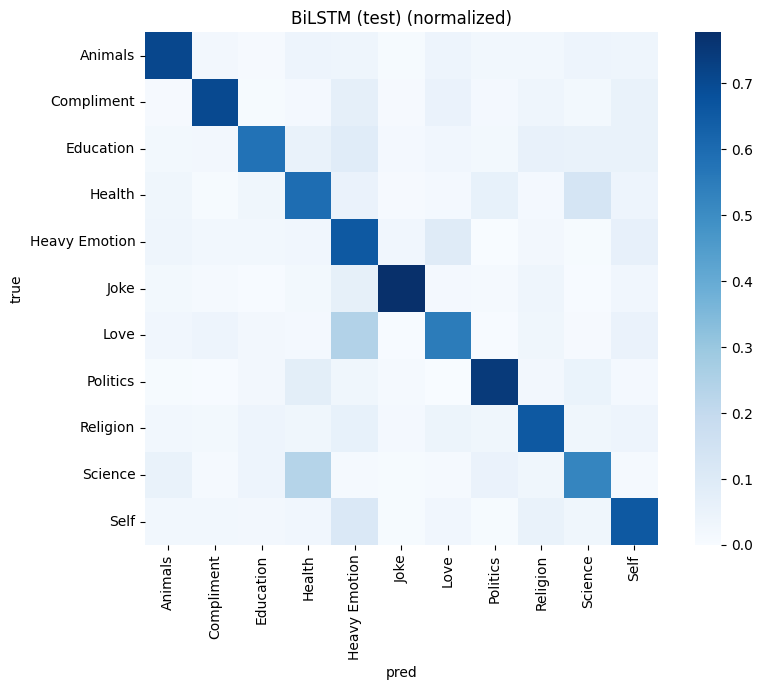

In [ ]:
bilstm_artifact = train_word_model(
    name="bilstm",
    model=BiLSTMClassifier(vocab_size=len(vocab), num_labels=num_labels),
    train_loader=train_loader_word,
    val_loader=val_loader_word,
    test_loader=test_loader_word,
    use_lengths=True,
    epochs=CFG.epochs_word,
    lr=CFG.lr_word,
    patience=CFG.patience,
)
artifacts["bilstm"] = bilstm_artifact
plot_confusion(bilstm_artifact["test"]["y_true"], bilstm_artifact["test"]["y_pred"], id2label, "BiLSTM (test)")


<!-- report-comment:bilstm -->

#### Phân tích Cell: Huấn luyện BiLSTM
- Chức năng cell: Huấn luyện và đánh giá BiLSTM trên dữ liệu word-level.
- Output chính: Test `accuracy = 0.6475`, `macro_f1 = 0.6528`; train F1 tăng nhanh nhưng val F1 tăng chậm và sớm bão hòa.
- Nhận xét từ output: Có dấu hiệu overfitting (train-val gap lớn ở các epoch cuối). BiLSTM chưa vượt baseline trong cấu hình hiện tại.


[bigru] epoch 01 | 18.5s | train_f1=0.4272 | val_f1=0.5376
[bigru] epoch 02 | 20.2s | train_f1=0.6169 | val_f1=0.6151
[bigru] epoch 03 | 35.6s | train_f1=0.7196 | val_f1=0.6336
[bigru] epoch 04 | 17.1s | train_f1=0.7954 | val_f1=0.6341
[bigru] epoch 05 | 17.5s | train_f1=0.8541 | val_f1=0.6454
[bigru] epoch 06 | 17.9s | train_f1=0.8971 | val_f1=0.6431
[bigru] epoch 07 | 17.1s | train_f1=0.9227 | val_f1=0.6447
[bigru] early stopping
[bigru] test: {'loss': 1.2158894777297973, 'accuracy': 0.6494417862838916, 'macro_f1': 0.6540034827607619, 'micro_f1': 0.6494417862838916}


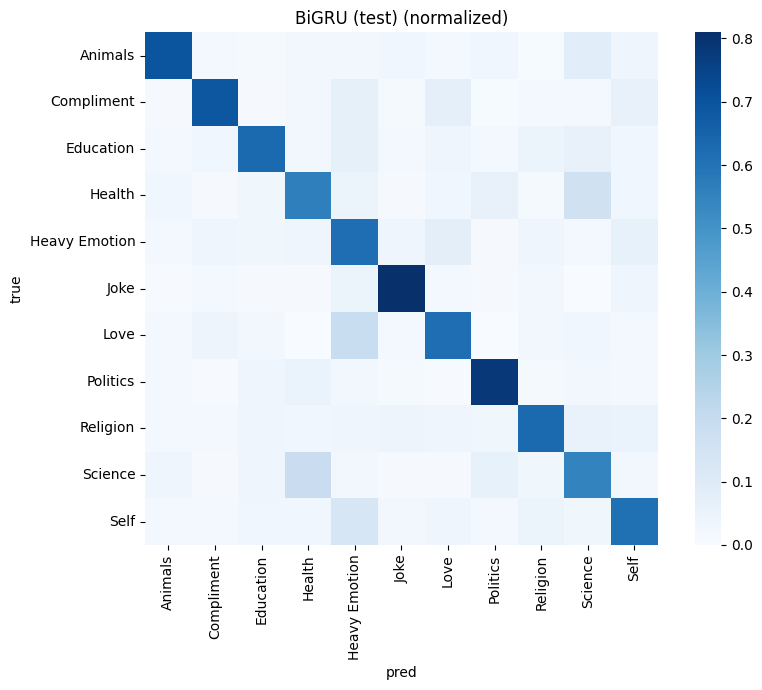

In [ ]:
gru_artifact = train_word_model(
    name="bigru",
    model=BiGRUClassifier(vocab_size=len(vocab), num_labels=num_labels),
    train_loader=train_loader_word,
    val_loader=val_loader_word,
    test_loader=test_loader_word,
    use_lengths=True,
    epochs=CFG.epochs_word,
    lr=CFG.lr_word,
    patience=CFG.patience,
)
artifacts["bigru"] = gru_artifact
plot_confusion(gru_artifact["test"]["y_true"], gru_artifact["test"]["y_pred"], id2label, "BiGRU (test)")

<!-- report-comment:bigru -->

#### Phân tích Cell: Huấn luyện BiGRU
- Chức năng cell: Huấn luyện và đánh giá BiGRU với cùng pipeline so sánh.
- Output chính: Test `accuracy = 0.6494`, `macro_f1 = 0.6540`.
- Nhận xét từ output: BiGRU nhỉnh hơn BiLSTM nhẹ, nhưng vẫn thấp hơn baseline TF-IDF+SVM và thấp hơn rõ rệt so với Transformer.


#### Nhóm mô hình Transformer (BERT / DistilBERT)


In [ ]:
class HFDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["Text"].tolist()
        self.labels = frame["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {"text": self.texts[idx], "labels": self.labels[idx]}


def make_hf_loaders(tokenizer, train_df, val_df, test_df, batch_size: int, max_len: int):
    def collate_fn(batch):
        texts = [b["text"] for b in batch]
        labels = torch.tensor([b["labels"] for b in batch], dtype=torch.long)
        enc = tokenizer(texts, truncation=True, max_length=max_len, padding=False, return_tensors=None)
        enc["labels"] = labels
        return enc

    collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True, return_tensors="pt")

    train_ds = HFDataset(train_df)
    val_ds = HFDataset(val_df)
    test_ds = HFDataset(test_df)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=lambda b: collator(collate_fn(b)))
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=lambda b: collator(collate_fn(b)))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=lambda b: collator(collate_fn(b)))
    return train_loader, val_loader, test_loader


def run_epoch_hf(model, loader, optimizer=None, scheduler=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, n = 0.0, 0
    all_y, all_pred, all_prob = [], [], []

    for batch in loader:
        batch = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            out = model(**batch)
            loss = out.loss
            logits = out.logits

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()

        probs = torch.softmax(logits, dim=-1)
        pred = probs.argmax(dim=-1)
        y = batch["labels"]

        total_loss += float(loss.item()) * len(y)
        n += len(y)

        all_y.extend(y.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())
        all_prob.extend(probs.detach().cpu().numpy().tolist())

    y_true = np.asarray(all_y)
    y_pred = np.asarray(all_pred)
    y_prob = np.asarray(all_prob)
    metrics = compute_metrics(y_true, y_pred)
    return total_loss / max(1, n), metrics, (y_true, y_pred, y_prob)


#####Full Fine Tuning (Berts/Distill Berts)

In [ ]:
def train_hf_model(name: str, model_name: str, train_df, val_df, test_df, id2label, label2id, epochs: int, lr: float, weight_decay: float, warmup_ratio: float, batch_size: int, max_len: int, attn_eager: bool = False):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_loader, val_loader, test_loader = make_hf_loaders(tokenizer, train_df, val_df, test_df, batch_size=batch_size, max_len=max_len)

    kwargs = {
        "num_labels": len(label2id),
        "id2label": id2label,
        "label2id": label2id,
    }
    if attn_eager:
        kwargs["attn_implementation"] = "eager"

    model = AutoModelForSequenceClassification.from_pretrained(model_name, **kwargs).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val = -1.0
    best_state = None
    patience_left = CFG.patience
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_m, _ = run_epoch_hf(model, train_loader, optimizer=optimizer, scheduler=scheduler, scaler=scaler)
        val_loss, val_m, _ = run_epoch_hf(model, val_loader, optimizer=None)
        dt = time.time() - t0

        history["train"].append({"loss": train_loss, **train_m})
        history["val"].append({"loss": val_loss, **val_m})

        print(f"[{name}] epoch {epoch:02d} | {dt/60:.1f}m | train_f1={train_m['macro_f1']:.4f} | val_f1={val_m['macro_f1']:.4f}")

        if val_m["macro_f1"] > best_val + 1e-4:
            best_val = val_m["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_left = CFG.patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"[{name}] early stopping")
                break

    model.load_state_dict(best_state)
    test_loss, test_m, (y_true, y_pred, y_prob) = run_epoch_hf(model, test_loader, optimizer=None)
    print(f"[{name}] test:", {"loss": test_loss, **test_m})

    return {
        "name": name,
        "family": "hf_torch",
        "model": model,
        "tokenizer": tokenizer,
        "history": history,
        "model_name": model_name,
        "val": None,
        "test": {
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "metrics": test_m,
        },
    }



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_635/2001969368.py:56: 

[bert_base] epoch 01 | 4.4m | train_f1=0.5864 | val_f1=0.7528
[bert_base] epoch 02 | 4.3m | train_f1=0.8008 | val_f1=0.7745
[bert_base] epoch 03 | 4.4m | train_f1=0.8847 | val_f1=0.7673
[bert_base] epoch 04 | 4.4m | train_f1=0.9346 | val_f1=0.7635
[bert_base] early stopping
[bert_base] test: {'loss': 0.7211870453954694, 'accuracy': 0.7763955342902711, 'macro_f1': 0.7829434987032626, 'micro_f1': 0.7763955342902711}


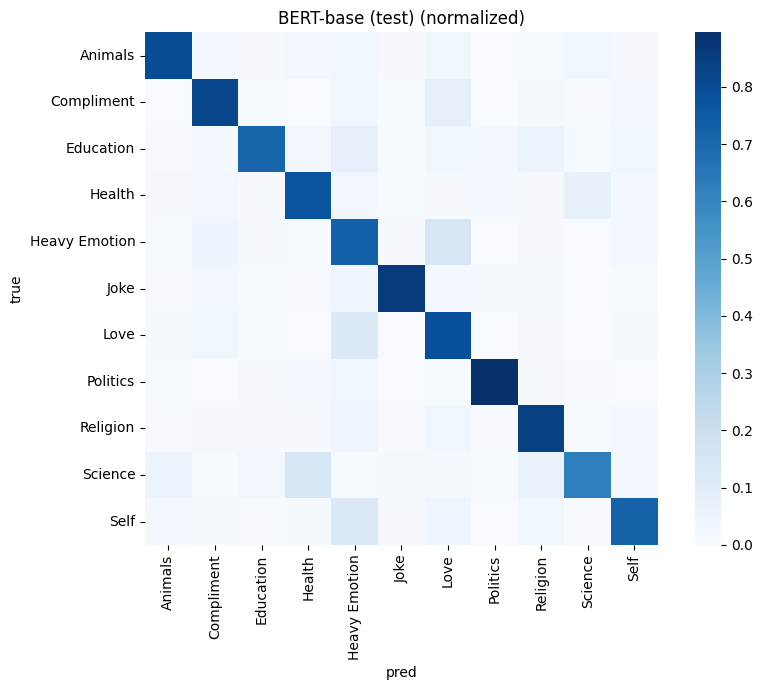

In [ ]:
bert_artifact = train_hf_model(
    name="bert_base",
    model_name=CFG.bert_name,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    id2label=id2label,
    label2id=label2id,
    epochs=CFG.epochs_hf,
    lr=CFG.lr_hf,
    weight_decay=CFG.weight_decay,
    warmup_ratio=CFG.warmup_ratio,
    batch_size=CFG.batch_size_hf,
    max_len=CFG.max_len,
    attn_eager=True,
)
artifacts["bert_base"] = bert_artifact
plot_confusion(bert_artifact["test"]["y_true"], bert_artifact["test"]["y_pred"], id2label, "BERT-base (test)")

<!-- report-comment:bert_base -->

#### Phân tích Cell: Huấn luyện BERT-base
- Chức năng cell: Fine-tune BERT-base cho phân loại đa lớp.
- Output chính: Test `accuracy = 0.7764`, `macro_f1 = 0.7829` (cao nhất toàn bộ thí nghiệm).
- Nhận xét từ output: BERT-base cho chất lượng tốt nhất. Log `UNEXPECTED/MISSING` khi load pretrain checkpoint là phù hợp do khác head tác vụ; early stopping giúp dừng đúng lúc khi val không cải thiện.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[distilbert] epoch 01 | 2.1m | train_f1=0.5925 | val_f1=0.7276
[distilbert] epoch 02 | 2.1m | train_f1=0.7853 | val_f1=0.7554
[distilbert] epoch 03 | 2.1m | train_f1=0.8613 | val_f1=0.7522
[distilbert] epoch 04 | 2.1m | train_f1=0.9154 | val_f1=0.7538
[distilbert] early stopping
[distilbert] test: {'loss': 0.7563492528179235, 'accuracy': 0.7610845295055821, 'macro_f1': 0.7663280018478528, 'micro_f1': 0.7610845295055821}


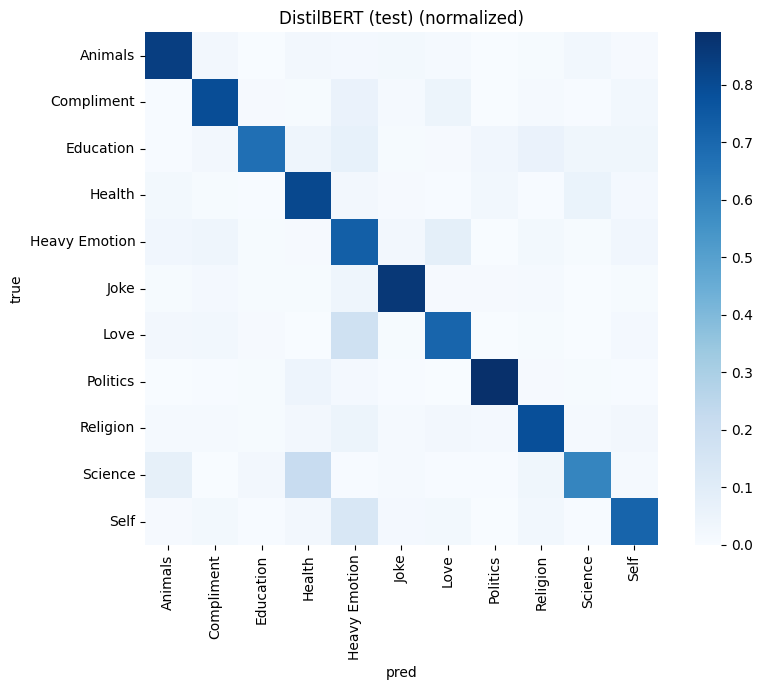

In [ ]:
distil_artifact = train_hf_model(
    name="distilbert",
    model_name=CFG.distil_name,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    id2label=id2label,
    label2id=label2id,
    epochs=CFG.epochs_hf,
    lr=CFG.lr_hf,
    weight_decay=CFG.weight_decay,
    warmup_ratio=CFG.warmup_ratio,
    batch_size=CFG.batch_size_hf,
    max_len=CFG.max_len,
    attn_eager=False,
)
artifacts["distilbert"] = distil_artifact
plot_confusion(distil_artifact["test"]["y_true"], distil_artifact["test"]["y_pred"], id2label, "DistilBERT (test)")


<!-- report-comment:distilbert -->

#### Phân tích Cell: Huấn luyện DistilBERT
- Chức năng cell: Fine-tune DistilBERT để so sánh với BERT-base theo hướng nhẹ hơn.
- Output chính: Test `accuracy = 0.7611`, `macro_f1 = 0.7663`.
- Nhận xét từ output: DistilBERT giữ chất lượng cao, chỉ thấp hơn BERT-base một khoảng vừa phải nhưng chi phí huấn luyện/suy luận thấp hơn đáng kể.


##### Freeze Backbone and Layerwise LR Fine Tuning (Distil Berts)

In [ ]:
# Fine-tune strategy comparison (freeze backbone vs full fine-tune vs layer-wise LR decay)
FT_RUN_STRATEGY_COMPARE = True

# To save time, default to DistilBERT. Add ("bert_base", CFG.bert_name) if you want both.
FT_COMPARE_BACKBONES = [
    ("distilbert", CFG.distil_name),
]
FT_STRATEGIES = ["freeze_backbone", "layerwise_lr"]
FT_LAYER_DECAY = 0.90
FT_EPOCHS = CFG.epochs_hf
FT_PATIENCE = CFG.patience

# Important: register strategy models into artifacts for downstream evaluation cells.
FT_REGISTER_TO_ARTIFACTS = True
FT_SAVE_CHECKPOINTS = True


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def _num_encoder_layers(model) -> int:
    base = model.base_model
    if hasattr(base, "encoder") and hasattr(base.encoder, "layer"):
        return len(base.encoder.layer)
    if hasattr(base, "transformer") and hasattr(base.transformer, "layer"):
        return len(base.transformer.layer)
    return 0


def build_optimizer_hf_strategy(model, strategy: str, lr: float, weight_decay: float, layer_decay: float = 0.90):
    for p in model.parameters():
        p.requires_grad = True

    if strategy == "freeze_backbone":
        if not hasattr(model, "base_model"):
            raise ValueError("Model does not expose .base_model for freezing")
        for p in model.base_model.parameters():
            p.requires_grad = False
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    if strategy == "full_finetune":
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    if strategy == "layerwise_lr":
        if not (0.0 < layer_decay <= 1.0):
            raise ValueError("layer_decay must be in (0, 1]")

        n_layers = _num_encoder_layers(model)
        max_depth = n_layers + 2
        groups: Dict[float, Dict[str, object]] = {}

        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue

            depth = n_layers + 1
            m = re.search(r"encoder\.layer\.(\d+)\.", name)
            if m is not None:
                depth = int(m.group(1)) + 1
            else:
                m = re.search(r"transformer\.layer\.(\d+)\.", name)
                if m is not None:
                    depth = int(m.group(1)) + 1
                elif ".embeddings." in name:
                    depth = 0
                elif name.startswith("classifier") or name.startswith("pre_classifier") or ".classifier." in name:
                    depth = n_layers + 2

            group_lr = lr * (layer_decay ** (max_depth - depth))
            key = round(float(group_lr), 12)
            if key not in groups:
                groups[key] = {"params": [], "lr": float(group_lr), "weight_decay": weight_decay}
            groups[key]["params"].append(p)

        return torch.optim.AdamW(list(groups.values()))

    raise ValueError(f"Unknown strategy: {strategy}")


def train_hf_model_with_strategy(
    name: str,
    model_name: str,
    strategy: str,
    train_df,
    val_df,
    test_df,
    id2label,
    label2id,
    epochs: int,
    lr: float,
    weight_decay: float,
    warmup_ratio: float,
    batch_size: int,
    max_len: int,
    patience: int,
    layer_decay: float = 0.90,
):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_loader, val_loader, test_loader = make_hf_loaders(tokenizer, train_df, val_df, test_df, batch_size=batch_size, max_len=max_len)

    kwargs = {
        "num_labels": len(label2id),
        "id2label": id2label,
        "label2id": label2id,
    }
    if model_name == CFG.bert_name:
        kwargs["attn_implementation"] = "eager"

    model = AutoModelForSequenceClassification.from_pretrained(model_name, **kwargs).to(DEVICE)

    optimizer = build_optimizer_hf_strategy(
        model=model,
        strategy=strategy,
        lr=lr,
        weight_decay=weight_decay,
        layer_decay=layer_decay,
    )

    trainable_params = count_trainable_params(model)

    total_steps = max(1, len(train_loader) * max(1, epochs))
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val = -1.0
    best_state = None
    patience_left = patience
    history = {"train": [], "val": []}

    total_train_seconds = 0.0

    for epoch in range(1, epochs + 1):
        t_train0 = time.time()
        train_loss, train_m, _ = run_epoch_hf(model, train_loader, optimizer=optimizer, scheduler=scheduler, scaler=scaler)
        train_seconds = time.time() - t_train0

        val_loss, val_m, _ = run_epoch_hf(model, val_loader, optimizer=None)
        total_train_seconds += train_seconds

        history["train"].append({"loss": train_loss, "train_seconds": train_seconds, **train_m})
        history["val"].append({"loss": val_loss, **val_m})

        print(
            f"[{name}:{strategy}] epoch {epoch:02d} | train={train_seconds:.1f}s | "
            f"train_f1={train_m['macro_f1']:.4f} | val_f1={val_m['macro_f1']:.4f}"
        )

        if val_m["macro_f1"] > best_val + 1e-4:
            best_val = val_m["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"[{name}:{strategy}] early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_m, (y_true, y_pred, y_prob) = run_epoch_hf(model, test_loader, optimizer=None)
    print(f"[{name}:{strategy}] test:", {"loss": test_loss, **test_m})

    return {
        "name": name,
        "model_name": model_name,
        "strategy": strategy,
        "model": model,
        "tokenizer": tokenizer,
        "history": history,
        "trainable_params": trainable_params,
        "best_val_macro_f1": float(best_val),
        "train_seconds": float(total_train_seconds),
        "test": {
            "loss": float(test_loss),
            "metrics": test_m,
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
        },
    }


finetune_strategy_runs: Dict[str, dict] = {}
finetune_strategy_df = None

if FT_RUN_STRATEGY_COMPARE:
    rows = []

    for backbone_name, model_name in FT_COMPARE_BACKBONES:
        for strategy in FT_STRATEGIES:
            run = train_hf_model_with_strategy(
                name=backbone_name,
                model_name=model_name,
                strategy=strategy,
                train_df=train_df,
                val_df=val_df,
                test_df=test_df,
                id2label=id2label,
                label2id=label2id,
                epochs=FT_EPOCHS,
                lr=CFG.lr_hf,
                weight_decay=CFG.weight_decay,
                warmup_ratio=CFG.warmup_ratio,
                batch_size=CFG.batch_size_hf,
                max_len=CFG.max_len,
                patience=FT_PATIENCE,
                layer_decay=FT_LAYER_DECAY,
            )

            key = f"{backbone_name}:{strategy}"
            art_name = f"{backbone_name}_{strategy}"
            finetune_strategy_runs[key] = run

            if FT_REGISTER_TO_ARTIFACTS:
                artifacts[art_name] = {
                    "name": art_name,
                    "family": "hf_torch",
                    "model": run["model"],
                    "tokenizer": run["tokenizer"],
                    "history": run["history"],
                    "model_name": run["model_name"],
                    "strategy": strategy,
                    "val": None,
                    "test": {
                        "y_true": run["test"]["y_true"],
                        "y_pred": run["test"]["y_pred"],
                        "y_prob": run["test"]["y_prob"],
                        "metrics": run["test"]["metrics"],
                    },
                }

            if FT_SAVE_CHECKPOINTS:
                os.makedirs(CFG.artifact_dir, exist_ok=True)
                ckpt_path = os.path.join(CFG.artifact_dir, f"{art_name}_clean.pt")
                state_cpu = {k: v.detach().cpu() for k, v in run["model"].state_dict().items()}
                torch.save(
                    {
                        "name": art_name,
                        "family": "hf_torch",
                        "state_dict": state_cpu,
                        "label2id": label2id,
                        "id2label": id2label,
                        "max_len": CFG.max_len,
                        "model_name": run["model_name"],
                        "strategy": strategy,
                    },
                    ckpt_path,
                )
                print("saved:", ckpt_path)

            rows.append({
                "artifact_name": art_name,
                "backbone": backbone_name,
                "strategy": strategy,
                "trainable_params": int(run["trainable_params"]),
                "best_val_macro_f1": float(run["best_val_macro_f1"]),
                "test_accuracy": float(run["test"]["metrics"]["accuracy"]),
                "test_macro_f1": float(run["test"]["metrics"]["macro_f1"]),
                "train_minutes": float(run["train_seconds"] / 60.0),
            })

    finetune_strategy_df = pd.DataFrame(rows).sort_values(
        ["backbone", "test_accuracy", "test_macro_f1"], ascending=[True, False, False]
    )

    print("Fine-tune strategy comparison (accuracy + training time):")
    display(finetune_strategy_df)
    if FT_REGISTER_TO_ARTIFACTS:
        print("Registered strategy models into artifacts:")
        print([r["artifact_name"] for r in rows])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[distilbert:freeze_backbone] epoch 01 | train=32.9s | train_f1=0.2898 | val_f1=0.5598
[distilbert:freeze_backbone] epoch 02 | train=32.0s | train_f1=0.5652 | val_f1=0.6253
[distilbert:freeze_backbone] epoch 03 | train=31.6s | train_f1=0.6011 | val_f1=0.6428
[distilbert:freeze_backbone] epoch 04 | train=32.8s | train_f1=0.6191 | val_f1=0.6608
[distilbert:freeze_backbone] epoch 05 | train=32.0s | train_f1=0.6321 | val_f1=0.6601
[distilbert:freeze_backbone] epoch 06 | train=32.3s | train_f1=0.6390 | val_f1=0.6663
[distilbert:freeze_backbone] epoch 07 | train=31.8s | train_f1=0.6440 | val_f1=0.6698
[distilbert:freeze_backbone] epoch 08 | train=32.3s | train_f1=0.6515 | val_f1=0.6758
[distilbert:freeze_backbone] epoch 09 | train=32.1s | train_f1=0.6535 | val_f1=0.6767
[distilbert:freeze_backbone] epoch 10 | train=31.9s | train_f1=0.6503 | val_f1=0.6747
[distilbert:freeze_backbone] test: {'loss': 1.028125868003334, 'accuracy': 0.6701754385964912, 'macro_f1': 0.6769109372451617, 'micro_f1': 0

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[distilbert:layerwise_lr] epoch 01 | train=120.7s | train_f1=0.5679 | val_f1=0.7339
[distilbert:layerwise_lr] epoch 02 | train=118.7s | train_f1=0.7627 | val_f1=0.7518
[distilbert:layerwise_lr] epoch 03 | train=119.1s | train_f1=0.8256 | val_f1=0.7546
[distilbert:layerwise_lr] epoch 04 | train=118.8s | train_f1=0.8707 | val_f1=0.7592
[distilbert:layerwise_lr] epoch 05 | train=118.6s | train_f1=0.9102 | val_f1=0.7518
[distilbert:layerwise_lr] epoch 06 | train=117.9s | train_f1=0.9332 | val_f1=0.7534
[distilbert:layerwise_lr] early stopping
[distilbert:layerwise_lr] test: {'loss': 0.8280973814320907, 'accuracy': 0.7668261562998405, 'macro_f1': 0.7716043090478544, 'micro_f1': 0.7668261562998405}
saved: /content/drive/MyDrive/deep_learning/artifacts/distilbert_layerwise_lr_clean.pt
Fine-tune strategy comparison (accuracy + training time):


,artifact_name,backbone,strategy,trainable_params,best_val_macro_f1,test_accuracy,test_macro_f1,train_minutes
1,distilbert_layerwise_lr,distilbert,layerwise_lr,66961931,0.759152,0.766826,0.771604,11.897305
0,distilbert_freeze_backbone,distilbert,freeze_backbone,599051,0.676684,0.670175,0.676911,5.360999


Registered strategy models into artifacts:
['distilbert_freeze_backbone', 'distilbert_layerwise_lr']


<!-- report-comment:ft_strategy -->

#### Phân tích Cell: So sánh chiến lược fine-tune (DistilBERT)
- Chức năng cell: Đối chiếu `freeze_backbone` và `layerwise_lr`.
- Output chính:
- `freeze_backbone`: test `macro_f1 = 0.6769`, train ~`5.36` phút.
- `layerwise_lr`: test `macro_f1 = 0.7716`, train ~`11.90` phút.
- Nhận xét từ output: Cập nhật encoder (đặc biệt layerwise LR) cải thiện chất lượng rất rõ so với chỉ train head. Đây là kết quả có giá trị học thuật và thực tiễn trong tối ưu fine-tuning.


### Đánh giá và so sánh kết quả của các mô hình


,accuracy,macro_f1,micro_f1,macro_precision,macro_recall,weighted_precision,weighted_recall,weighted_f1
model,,,,,,,,
bert_base,0.776396,0.782943,0.776396,0.794028,0.777412,0.784232,0.776396,0.777559
distilbert_layerwise_lr,0.766826,0.771604,0.766826,0.777619,0.771456,0.773340,0.766826,0.767224
distilbert,0.761085,0.766328,0.761085,0.775806,0.764085,0.769375,0.761085,0.761705
tfidf_svm,0.675598,0.682553,0.675598,0.689130,0.678685,0.682639,0.675598,0.677751
distilbert_freeze_backbone,0.670175,0.676911,0.670175,0.682272,0.674608,0.673258,0.670175,0.670307
bigru,0.649442,0.654003,0.649442,0.657264,0.653992,0.655993,0.649442,0.651006
bilstm,0.647528,0.652775,0.647528,0.660756,0.649246,0.656595,0.647528,0.649628


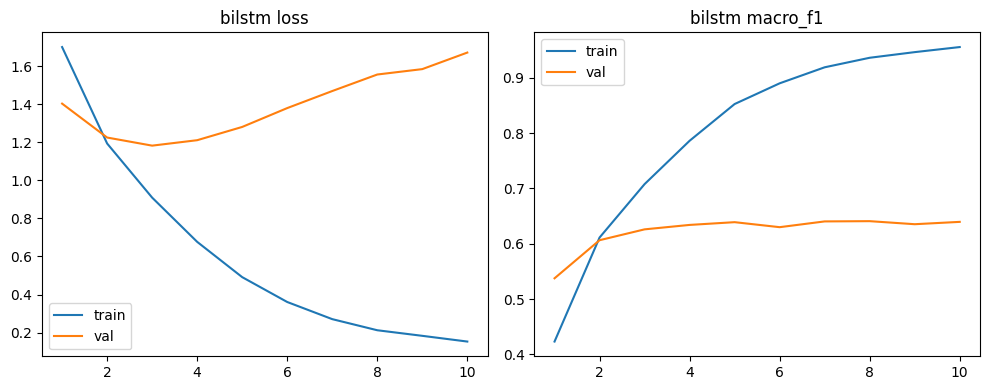

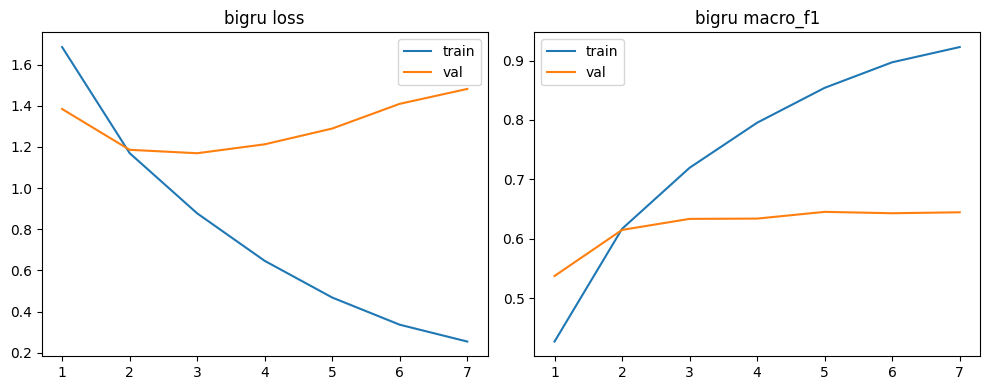

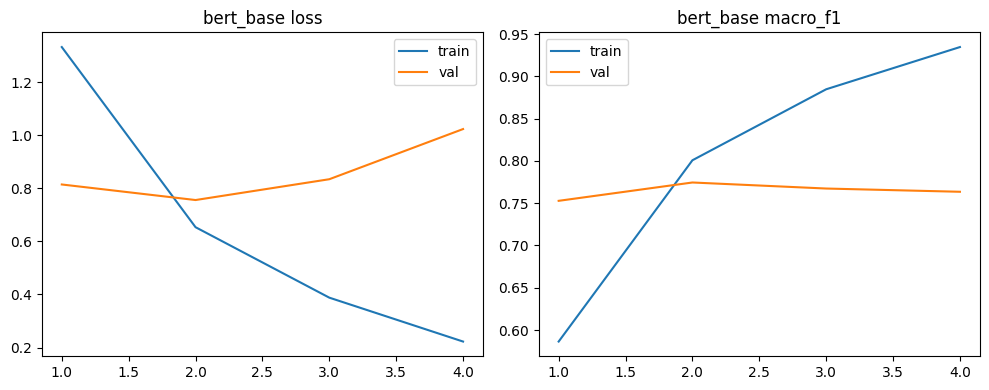

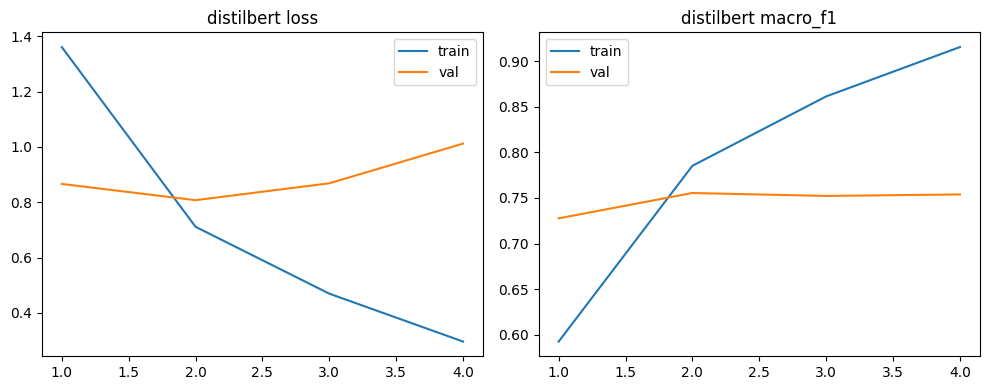

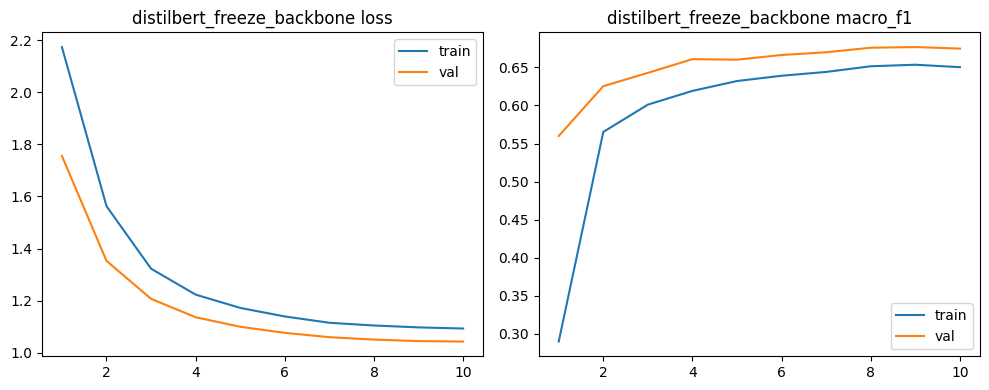

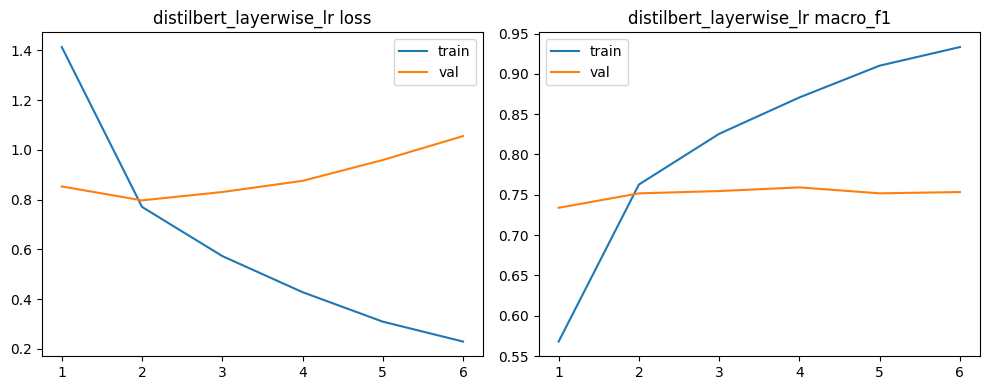

In [ ]:
def plot_history(history: Optional[Dict[str, List[Dict[str, float]]]], title: str):
    if history is None:
        print(f"{title}: no training history")
        return

    epochs = range(1, len(history["train"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, [x["loss"] for x in history["train"]], label="train")
    axes[0].plot(epochs, [x["loss"] for x in history["val"]], label="val")
    axes[0].set_title(f"{title} loss")
    axes[0].legend()

    axes[1].plot(epochs, [x["macro_f1"] for x in history["train"]], label="train")
    axes[1].plot(epochs, [x["macro_f1"] for x in history["val"]], label="val")
    axes[1].set_title(f"{title} macro_f1")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

rows = []
for name, art in artifacts.items():
    y_true = art["test"]["y_true"]
    y_pred = art["test"]["y_pred"]
    rows.append({"model": name, **compute_extended_metrics(y_true, y_pred)})

results_df = pd.DataFrame(rows).set_index("model").sort_values("macro_f1", ascending=False)
display(results_df)

for name in ["bilstm", "bigru", "bert_base", "distilbert", "distilbert_freeze_backbone", "distilbert_layerwise_lr"]:
    plot_history(artifacts[name]["history"], name)


<!-- report-comment:results_compare -->

#### Phân tích Cell: Tổng hợp kết quả mô hình
- Chức năng cell: Gom kết quả tất cả mô hình, vẽ learning curves và bảng so sánh đa metric.
- Output chính: Thứ hạng macro-F1: `BERT-base (0.7829)` > `DistilBERT layerwise (0.7716)` > `DistilBERT (0.7663)` > nhóm còn lại.
- Nhận xét từ output: Kết quả nhất quán giữa nhiều metric (accuracy, macro/weighted F1), củng cố kết luận Transformer vượt trội trong bài toán này.


###Phân tích lỗi (Error Analysis)

In [ ]:
def predict_proba_baseline(artifact: dict, texts: List[str]) -> np.ndarray:
    x_texts = [bert_pretokenize_text(t) for t in texts]
    X = artifact["vectorizer"].transform(x_texts)
    return artifact["model"].predict_proba(X)


def _batch_ids_from_texts(texts: List[str], vocab: Dict[str, int], max_len: int, pad_id: int):
    seqs = []
    lengths = []
    for t in texts:
        ids = numericalize(simple_tokenize(t), vocab)[:max_len]
        if len(ids) == 0:
            ids = [int(vocab.get(UNK_TOKEN, UNK_ID))]
        seqs.append(ids)
        lengths.append(len(ids))

    max_batch = min(max(lengths), max_len)
    arr = torch.full((len(seqs), max_batch), fill_value=pad_id, dtype=torch.long)
    for i, ids in enumerate(seqs):
        ids = ids[:max_batch]
        arr[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)

    return arr, torch.tensor(lengths, dtype=torch.long).clamp(max=max_len)


def predict_proba_word(artifact: dict, texts: List[str], batch_size: int = 128) -> np.ndarray:
    model = artifact["model"]
    model.eval()
    vocab = artifact["vocab"]
    use_lengths = artifact["use_lengths"]
    pad_id = int(vocab.get(PAD_TOKEN, PAD_ID))

    probs_all = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            input_ids, lengths = _batch_ids_from_texts(batch, vocab, CFG.max_len, pad_id)
            input_ids = input_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            logits = model(input_ids, lengths) if use_lengths else model(input_ids)
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            probs_all.append(probs)

    return np.vstack(probs_all) if probs_all else np.zeros((0, len(label2id)))


def predict_proba_hf(artifact: dict, texts: List[str], batch_size: int = 64) -> np.ndarray:
    model = artifact["model"]
    tok = artifact["tokenizer"]
    model.eval()

    probs_all = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tok(batch, truncation=True, max_length=CFG.max_len, padding=True, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            probs_all.append(probs)

    return np.vstack(probs_all) if probs_all else np.zeros((0, len(label2id)))


def predict_proba_any(name: str, texts: List[str], batch_size: int = 64) -> np.ndarray:
    art = artifacts[name]
    if art["family"] == "sklearn":
        return predict_proba_baseline(art, texts)
    if art["family"] == "word_torch":
        return predict_proba_word(art, texts, batch_size=batch_size)
    if art["family"] == "hf_torch":
        return predict_proba_hf(art, texts, batch_size=batch_size)
    raise ValueError(f"Unknown family: {art['family']}")


In [ ]:
def error_analysis_all_models(artifacts: Dict[str, dict], test_df: pd.DataFrame, id2label: Dict[int, str], top_k: int = 20):
    rows = []
    confusion_rows = []

    for name, art in artifacts.items():
        y_true = np.asarray(art["test"]["y_true"])
        y_pred = np.asarray(art["test"]["y_pred"])
        y_prob = np.asarray(art["test"]["y_prob"])

        conf = y_prob.max(axis=1)
        wrong = np.where(y_true != y_pred)[0]
        rank = wrong[np.argsort(-conf[wrong])]

        for i in rank[:top_k]:
            rows.append({
                "model": name,
                "true": id2label[int(y_true[i])],
                "pred": id2label[int(y_pred[i])],
                "confidence": float(conf[i]),
                "text": test_df.loc[i, "Text"],
            })

        pair_df = pd.Series(list(zip(y_true, y_pred))).value_counts().reset_index()
        pair_df.columns = ["pair", "count"]
        pair_df = pair_df[pair_df["pair"].apply(lambda x: x[0] != x[1])]
        pair_df["true"] = pair_df["pair"].apply(lambda x: id2label[int(x[0])])
        pair_df["pred"] = pair_df["pair"].apply(lambda x: id2label[int(x[1])])
        pair_df = pair_df.sort_values("count", ascending=False).head(10)

        for _, r in pair_df.iterrows():
            confusion_rows.append({
                "model": name,
                "true": r["true"],
                "pred": r["pred"],
                "count": int(r["count"]),
            })

    return pd.DataFrame(rows), pd.DataFrame(confusion_rows)

high_conf_err_df, confusion_pairs_df = error_analysis_all_models(artifacts, test_df, id2label, top_k=20)

print("High-confidence wrong predictions (all models):")
display(high_conf_err_df[["model", "true", "pred", "confidence"]].head(30))

print("Top confusion pairs by model:")
display(confusion_pairs_df.head(60))


High-confidence wrong predictions (all models):


,model,true,pred,confidence
0,tfidf_svm,Self,Joke,0.999121
1,tfidf_svm,Education,Politics,0.998498
2,tfidf_svm,Heavy Emotion,Education,0.996913
3,tfidf_svm,Science,Health,0.995570
4,tfidf_svm,Religion,Politics,0.990473
5,tfidf_svm,Self,Religion,0.983662
6,tfidf_svm,Science,Self,0.974775
7,tfidf_svm,Religion,Compliment,0.970960
8,tfidf_svm,Self,Religion,0.963708
9,tfidf_svm,Compliment,Education,0.963169


Top confusion pairs by model:


,model,true,pred,count
0,tfidf_svm,Love,Heavy Emotion,49
1,tfidf_svm,Self,Heavy Emotion,36
2,tfidf_svm,Heavy Emotion,Love,32
3,tfidf_svm,Science,Health,28
4,tfidf_svm,Religion,Heavy Emotion,24
5,tfidf_svm,Health,Science,23
6,tfidf_svm,Compliment,Heavy Emotion,22
7,tfidf_svm,Education,Religion,21
8,tfidf_svm,Joke,Heavy Emotion,20
9,tfidf_svm,Education,Science,18


<!-- report-comment:error_analysis -->

#### Phân tích Cell: Error Analysis
- Chức năng cell: Trích các lỗi dự đoán sai confidence cao và các cặp nhầm lẫn phổ biến theo từng mô hình.
- Output chính: Các cặp lỗi lặp lại mạnh: `Love ↔ Heavy Emotion`, `Science ↔ Health`, `Self ↔ Heavy Emotion`.
- Nhận xét từ output: Sai số tập trung ở các lớp gần ngữ nghĩa, không phải lỗi ngẫu nhiên. Đây là dấu hiệu cần tăng dữ liệu hard-case theo cặp lớp và tinh chỉnh loss/augmentation theo nhóm nhãn.


###Calibration (ECE + reliability)


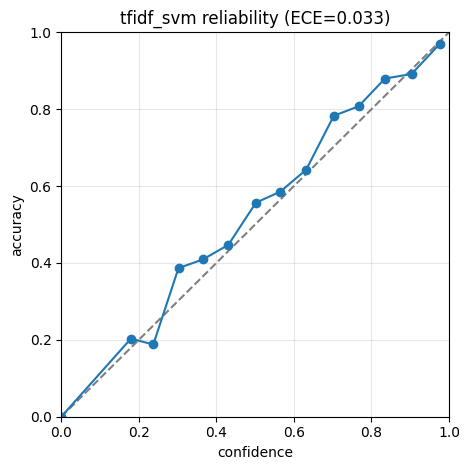

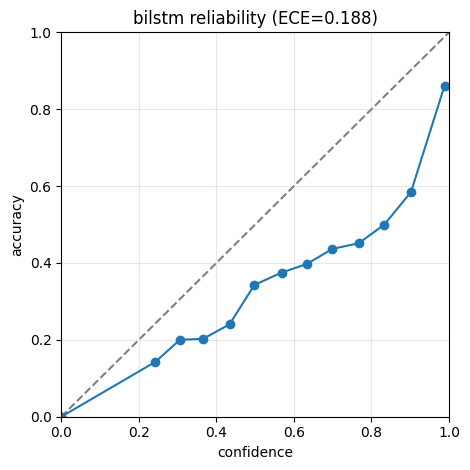

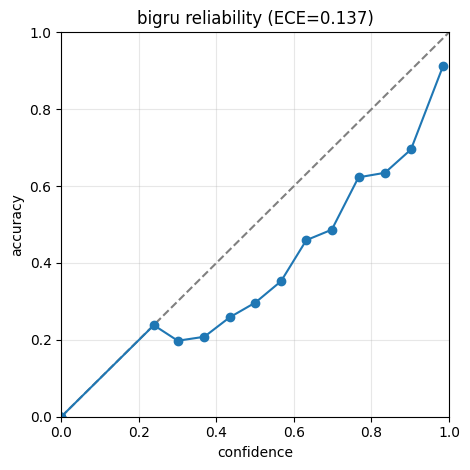

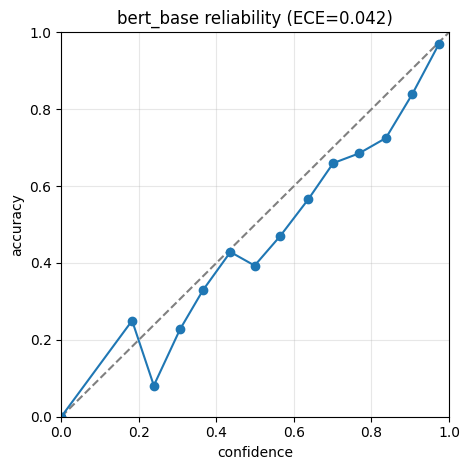

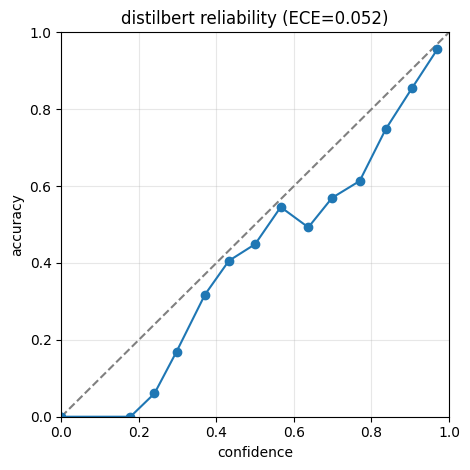

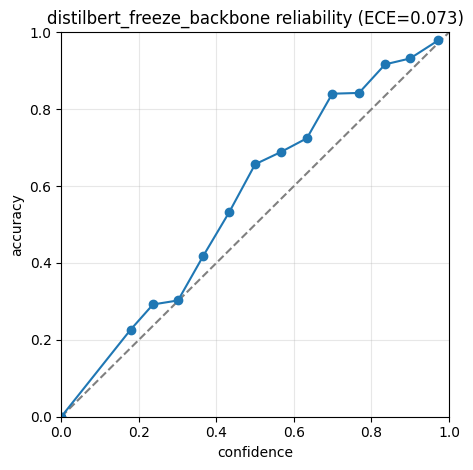

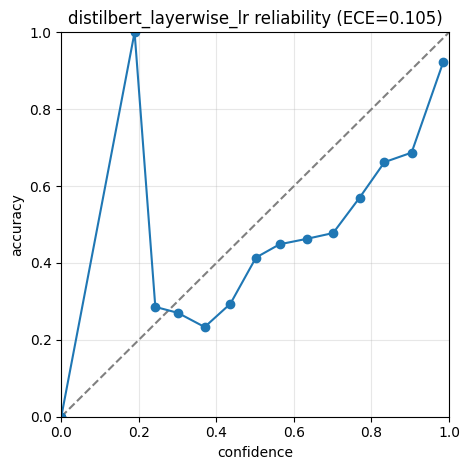

,model,ece
0,tfidf_svm,0.033442
3,bert_base,0.042488
4,distilbert,0.051535
5,distilbert_freeze_backbone,0.073247
6,distilbert_layerwise_lr,0.104679
2,bigru,0.137263
1,bilstm,0.187747


In [ ]:
def expected_calibration_error(probs: np.ndarray, y_true: np.ndarray, n_bins: int = 15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == y_true).astype(np.float64)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_acc, bin_conf, bin_frac = [], [], []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_frac.append(0.0)
            continue
        frac = mask.mean()
        a = acc[mask].mean()
        c = conf[mask].mean()
        ece += frac * abs(a - c)
        bin_acc.append(a)
        bin_conf.append(c)
        bin_frac.append(frac)

    return float(ece), np.array(bin_acc), np.array(bin_conf), np.array(bin_frac)


def plot_reliability(bin_acc, bin_conf, title: str):
    plt.figure(figsize=(4.8, 4.8))
    plt.plot([0, 1], [0, 1], "--", color="gray")
    x = np.nan_to_num(bin_conf, nan=0.0)
    y = np.nan_to_num(bin_acc, nan=0.0)
    plt.plot(x, y, marker="o")
    plt.xlabel("confidence")
    plt.ylabel("accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if CFG.run_calibration:
    ece_rows = []
    for name, art in artifacts.items():
        y_true = np.asarray(art["test"]["y_true"])
        y_prob = np.asarray(art["test"]["y_prob"])
        ece, bacc, bconf, _ = expected_calibration_error(y_prob, y_true, n_bins=15)
        ece_rows.append({"model": name, "ece": ece})
        plot_reliability(bacc, bconf, title=f"{name} reliability (ECE={ece:.3f})")

    ece_df = pd.DataFrame(ece_rows).sort_values("ece")
    display(ece_df)


<!-- report-comment:calibration -->

#### Phân tích Cell: Calibration (ECE)
- Chức năng cell: Đánh giá độ tin cậy xác suất dự đoán bằng ECE và reliability diagram.
- Output chính: ECE tốt nhất là `tfidf_svm = 0.0334`, tiếp theo `bert_base = 0.0425`, `distilbert = 0.0515`; cao nhất là `bilstm = 0.1877`.
- Nhận xét từ output: Độ chính xác cao chưa đồng nghĩa xác suất tin cậy. Khi triển khai theo ngưỡng confidence, calibration là tiêu chí bắt buộc cần xem cùng accuracy/F1.


###Robustness (noisy text)


In [ ]:
def perturb_random_delete(text: str, p: float = 0.1, seed: int = 0) -> str:
    rng = np.random.default_rng(seed)
    toks = str(text).split()
    if len(toks) <= 3:
        return text
    keep = rng.random(len(toks)) > p
    out = [t for t, k in zip(toks, keep) if k]
    return " ".join(out) if out else " ".join(toks[:1])


def perturb_random_swap(text: str, n_swaps: int = 1, seed: int = 0) -> str:
    rng = np.random.default_rng(seed)
    toks = str(text).split()
    if len(toks) <= 4:
        return text
    toks = toks[:]
    for _ in range(n_swaps):
        i, j = rng.integers(0, len(toks), size=2)
        toks[i], toks[j] = toks[j], toks[i]
    return " ".join(toks)


def evaluate_model_on_texts(name: str, texts: List[str], y_true: np.ndarray) -> Dict[str, float]:
    probs = predict_proba_any(name, texts, batch_size=64)
    preds = probs.argmax(axis=1)
    return compute_metrics(y_true, preds)

if CFG.run_robustness:
    sub = test_df.sample(n=min(3000, len(test_df)), random_state=CFG.seed).reset_index(drop=True)
    clean_texts = sub["Text"].tolist()
    y = sub["label"].values

    del_texts = [perturb_random_delete(t, p=0.12, seed=CFG.seed + i) for i, t in enumerate(clean_texts)]
    swap_texts = [perturb_random_swap(t, n_swaps=1, seed=CFG.seed + i) for i, t in enumerate(clean_texts)]

    rob_rows = []
    for name in artifacts.keys():
        clean_m = evaluate_model_on_texts(name, clean_texts, y)
        del_m = evaluate_model_on_texts(name, del_texts, y)
        swap_m = evaluate_model_on_texts(name, swap_texts, y)

        rob_rows.extend([
            {"model": name, "setting": "clean", **clean_m},
            {"model": name, "setting": "random_delete(p=0.12)", **del_m},
            {"model": name, "setting": "random_swap(n=1)", **swap_m},
        ])

    robustness_df = pd.DataFrame(rob_rows)
    display(robustness_df.sort_values(["model", "setting"]))


,model,setting,accuracy,macro_f1,micro_f1
9,bert_base,clean,0.777667,0.784169,0.777667
10,bert_base,random_delete(p=0.12),0.747000,0.754102,0.747000
11,bert_base,random_swap(n=1),0.759333,0.767560,0.759333
6,bigru,clean,0.649667,0.654418,0.649667
7,bigru,random_delete(p=0.12),0.627667,0.632356,0.627667
8,bigru,random_swap(n=1),0.645667,0.650384,0.645667
3,bilstm,clean,0.647333,0.652613,0.647333
4,bilstm,random_delete(p=0.12),0.624000,0.630095,0.624000
5,bilstm,random_swap(n=1),0.632333,0.637444,0.632333
12,distilbert,clean,0.761000,0.766050,0.761000


<!-- report-comment:robustness -->

#### Phân tích Cell: Robustness với nhiễu văn bản
- Chức năng cell: Đánh giá độ bền mô hình dưới hai kiểu nhiễu `random_delete` và `random_swap`.
- Output chính: Mọi mô hình đều giảm điểm; ví dụ BERT-base `macro_f1: 0.7842 -> 0.7541 (delete) -> 0.7676 (swap)`.
- Nhận xét từ output: Nhiễu xóa từ gây hại mạnh hơn đổi vị trí từ. Transformer vẫn giữ vị trí cao hơn nhóm còn lại trong kịch bản dữ liệu nhiễu.


###Khả năng giải thích (Interpretability)

Giải thích dự đoán cho toàn bộ model theo cùng API `artifacts`:
- `sklearn` (TF-IDF + SVM): local token importance theo TF-IDF của mẫu.
- `word_torch` (BiLSTM/BiGRU/Custom Transformer): gradient saliency theo token.
- `hf_torch` (BERT/DistilBERT): gradient saliency theo token.


sample: I don't seriously think we've ever seen what we'd call magic in our history. Rather, this bit in the texts about sorcerers and witches is like unicorns--it's a way of categorizing a certain kind of secular people who ...
[tfidf_svm] pred_label: Religion | confidence=0.9414


,token,tfidf
0,way,0.176305
1,it,0.155025
2,the,0.154325
3,if you,0.140792
4,which,0.137748
5,that,0.131362
6,which is,0.124959
7,in,0.116261
8,kind of,0.113901
9,of,0.111527


[bilstm] pred_label: Self | confidence=0.6400


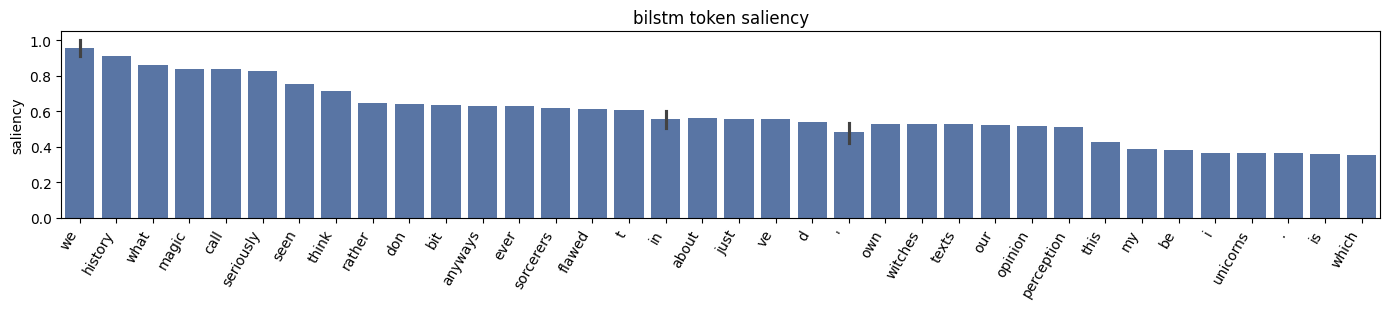

[bigru] pred_label: Religion | confidence=0.4342


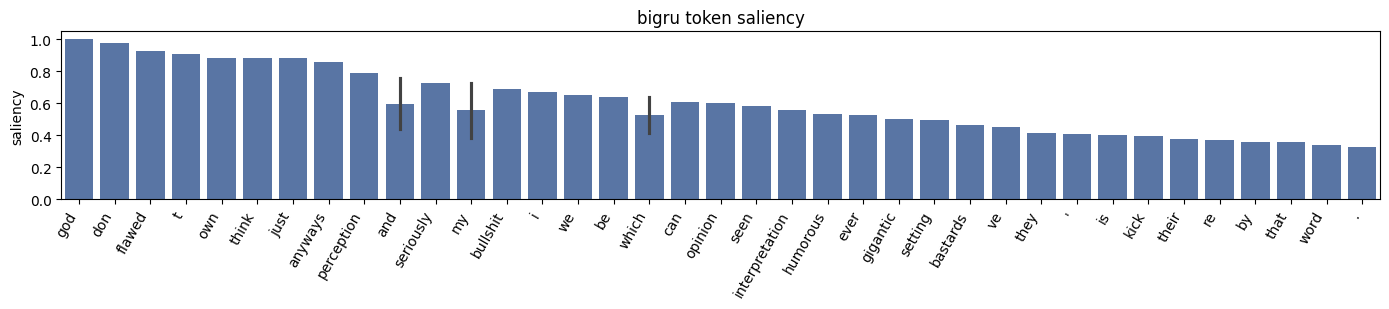

[bert_base] pred_label: Religion | confidence=0.9322


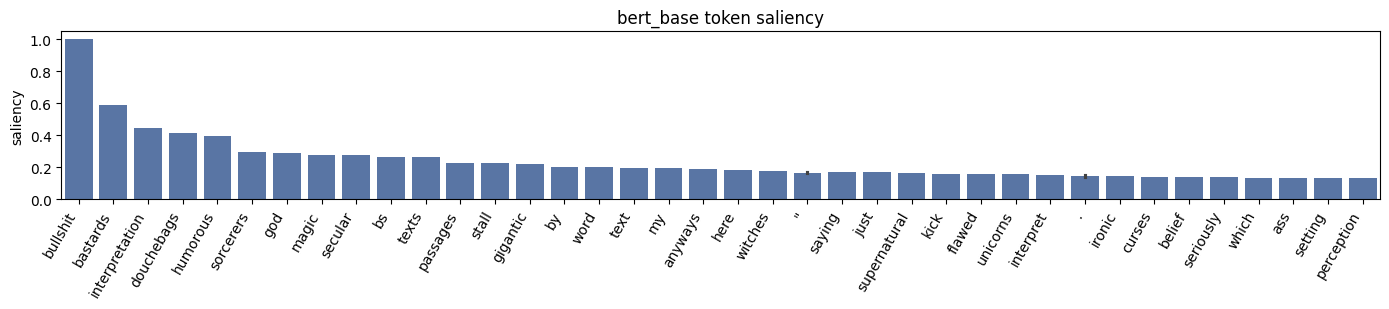

[distilbert] pred_label: Religion | confidence=0.5661


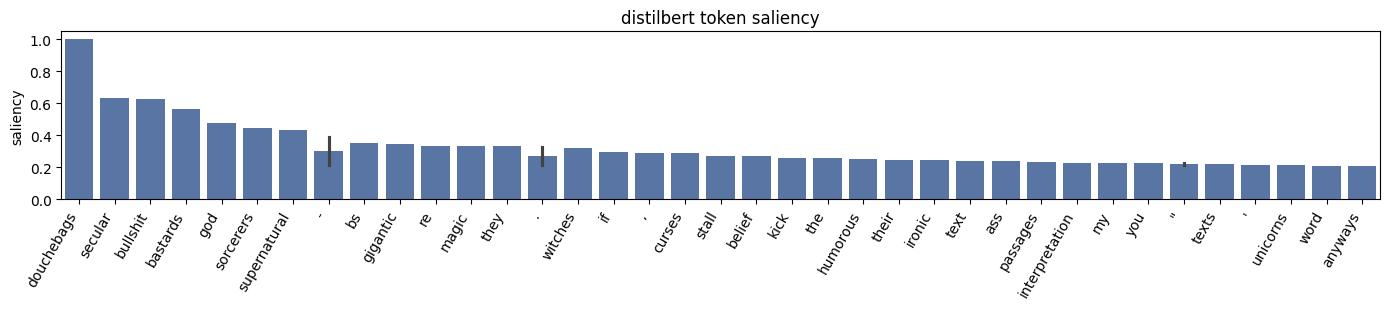

[distilbert_freeze_backbone] interpretability error: RuntimeError: can't retain_grad on Tensor that has requires_grad=False
[distilbert_layerwise_lr] pred_label: Religion | confidence=0.9398


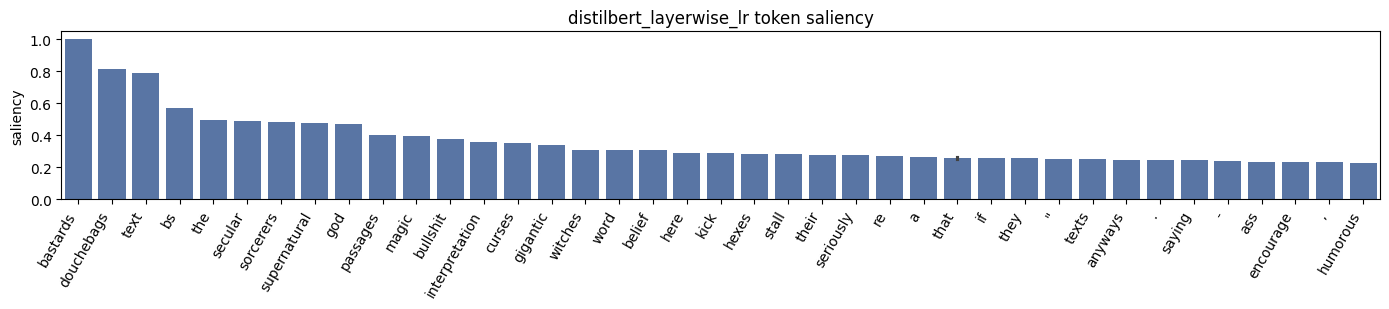


Prediction summary across all models:


,model,pred,confidence,status
0,distilbert_freeze_backbone,None,NaN,error: RuntimeError
1,tfidf_svm,Religion,0.941359,ok
2,distilbert_layerwise_lr,Religion,0.939810,ok
3,bert_base,Religion,0.932245,ok
4,bilstm,Self,0.640006,ok
5,distilbert,Religion,0.566111,ok
6,bigru,Religion,0.434239,ok


In [ ]:
RUN_INTERPRETABILITY = True


def preview_text(text: str, max_chars: int = 220) -> str:
    t = re.sub(r"\s+", " ", str(text)).strip()
    return t if len(t) <= max_chars else (t[: max_chars - 3] + "...")


def _prepare_tokens_for_plot(tokens, scores, top_k: int = 40):
    tokens = list(tokens)
    scores = np.asarray(scores, dtype=np.float32)
    if len(tokens) == 0 or len(scores) == 0:
        return [], np.array([])

    n = min(len(tokens), len(scores))
    tokens = tokens[:n]
    scores = scores[:n]

    # Remove common special tokens so charts focus on content words.
    special = {"[CLS]", "[SEP]", "[PAD]", "<s>", "</s>", "<pad>"}
    keep = [i for i, tok in enumerate(tokens) if tok not in special]
    if len(keep) > 0:
        tokens = [tokens[i] for i in keep]
        scores = scores[keep]

    # Merge BERT-style wordpieces: ["educ", "##ation"] -> ["education"]
    merged_tokens, merged_scores = [], []
    for tok, sc in zip(tokens, scores):
        if tok.startswith("##") and len(merged_tokens) > 0:
            merged_tokens[-1] = merged_tokens[-1] + tok[2:]
            merged_scores[-1] = max(merged_scores[-1], float(sc))
        else:
            merged_tokens.append(tok)
            merged_scores.append(float(sc))

    if len(merged_tokens) == 0:
        return [], np.array([])

    scores = np.asarray(merged_scores, dtype=np.float32)
    k = min(top_k, len(merged_tokens))
    top_idx = np.argsort(-scores)[:k]

    plot_tokens = [merged_tokens[i] for i in top_idx]
    plot_scores = scores[top_idx]
    return plot_tokens, plot_scores


def plot_token_scores(tokens, scores, title: str, top_k: int = 40):
    plot_tokens, plot_scores = _prepare_tokens_for_plot(tokens, scores, top_k=top_k)
    if len(plot_tokens) == 0:
        print(f"{title}: no non-special tokens to display")
        return

    plt.figure(figsize=(max(10, len(plot_tokens) * 0.35), 3.2))
    sns.barplot(x=plot_tokens, y=plot_scores, color="#4C72B0")
    plt.xticks(rotation=60, ha="right")
    plt.title(title)
    plt.ylabel("saliency")
    plt.tight_layout()
    plt.show()


def sklearn_local_tfidf_importance(artifact: dict, text: str, top_k: int = 25):
    vec = artifact["vectorizer"]
    model = artifact["model"]

    x_text = bert_pretokenize_text(text)
    X = vec.transform([x_text])
    probs = model.predict_proba(X)[0]
    pred = int(np.argmax(probs))

    row = X[0].tocoo()
    if row.nnz == 0:
        return pred, float(probs[pred]), pd.DataFrame(columns=["token", "tfidf"])

    feature_names = np.asarray(vec.get_feature_names_out())
    order = np.argsort(row.data)[::-1][:top_k]
    tok = feature_names[row.col[order]]
    val = row.data[order]

    return pred, float(probs[pred]), pd.DataFrame({"token": tok, "tfidf": val})


def _word_forward_with_embeds(model, embeds: torch.Tensor, lengths: torch.Tensor, input_ids: torch.Tensor, use_lengths: bool):
    if use_lengths and isinstance(model, BiLSTMClassifier):
        packed = nn.utils.rnn.pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = model.lstm(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = model.dropout(torch.cat([fw, bw], dim=1))
        return model.fc(h)

    if use_lengths and isinstance(model, BiGRUClassifier):
        packed = nn.utils.rnn.pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = model.gru(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = model.dropout(torch.cat([fw, bw], dim=1))
        return model.fc(h)

    if isinstance(model, TransformerEncoderClassifier):
        B, T = input_ids.shape
        T = min(T, model.max_len)
        input_ids = input_ids[:, :T]
        embeds = embeds[:, :T, :]

        pos = torch.arange(T, device=input_ids.device).unsqueeze(0).expand(B, T)
        x = embeds * (model.d_model ** 0.5)
        x = x + model.pos_emb(pos)

        pad_mask = make_padding_mask(input_ids, pad_id=model.pad_id)
        h = model.encoder(x, src_key_padding_mask=pad_mask)

        nonpad = (~pad_mask).float()
        denom = nonpad.sum(dim=1, keepdim=True).clamp(min=1.0)
        pooled = (h * nonpad.unsqueeze(-1)).sum(dim=1) / denom
        return model.fc(model.dropout(pooled))

    raise ValueError(f"Unsupported word model type: {type(model)}")


def word_model_saliency_from_artifact(artifact: dict, text: str, max_len: int = 256, target_label: Optional[int] = None):
    model = artifact["model"]
    vocab_local = artifact["vocab"]
    use_lengths = artifact["use_lengths"]

    was_training = model.training
    model.eval()

    try:
        tokens = simple_tokenize(text)[:max_len]
        if len(tokens) == 0:
            tokens = [UNK_TOKEN]

        ids = numericalize(tokens, vocab_local)
        input_ids = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
        lengths = torch.tensor([len(ids)], dtype=torch.long, device=DEVICE)

        emb_layer = model.embedding if hasattr(model, "embedding") else model.tok_emb
        embeds = emb_layer(input_ids)
        embeds.retain_grad()

        # CuDNN RNN backward in eval mode can fail for LSTM/GRU.
        use_cudnn_fallback = DEVICE.type == "cuda" and isinstance(model, (BiLSTMClassifier, BiGRUClassifier))
        if use_cudnn_fallback:
            with torch.backends.cudnn.flags(enabled=False):
                logits = _word_forward_with_embeds(model, embeds, lengths, input_ids, use_lengths)
        else:
            logits = _word_forward_with_embeds(model, embeds, lengths, input_ids, use_lengths)

        if target_label is None:
            target_label = int(logits.argmax(dim=-1).item())

        score = logits[0, target_label]
        model.zero_grad(set_to_none=True)
        score.backward()

        grads = embeds.grad.detach()
        sal = grads.norm(dim=-1).squeeze(0)
        sal = sal / (sal.max().clamp(min=1e-12))

        return tokens, sal.detach().cpu().numpy(), target_label
    finally:
        model.train(was_training)


def hf_model_saliency_from_artifact(artifact: dict, text: str, max_len: int = 256, target_label: Optional[int] = None):
    model = artifact["model"]
    tok = artifact["tokenizer"]

    was_training = model.training
    model.eval()

    try:
        enc = tok(text, truncation=True, max_length=max_len, return_tensors="pt")
        input_ids = enc["input_ids"].to(DEVICE)
        attn_mask = enc["attention_mask"].to(DEVICE)

        emb_layer = model.get_input_embeddings()
        inputs_embeds = emb_layer(input_ids)
        inputs_embeds.retain_grad()

        out = model(inputs_embeds=inputs_embeds, attention_mask=attn_mask)
        logits = out.logits

        if target_label is None:
            target_label = int(logits.argmax(dim=-1).item())

        score = logits[0, target_label]
        model.zero_grad(set_to_none=True)
        score.backward()

        grads = inputs_embeds.grad.detach()
        sal = grads.norm(dim=-1).squeeze(0)
        sal = sal * attn_mask.squeeze(0)
        sal = sal / (sal.max().clamp(min=1e-12))

        tokens = tok.convert_ids_to_tokens(input_ids.squeeze(0))
        return tokens, sal.detach().cpu().numpy(), target_label
    finally:
        model.train(was_training)


def interpret_all_models_on_sample(sample_text: str, artifacts: Dict[str, dict], id2label: Dict[int, str], top_k: int = 40):
    summary_rows = []

    for name, art in artifacts.items():
        family = art["family"]

        try:
            if family == "sklearn":
                pred, conf, local_df = sklearn_local_tfidf_importance(art, sample_text, top_k=min(25, top_k))
                summary_rows.append({"model": name, "pred": id2label[pred], "confidence": conf, "status": "ok"})
                print(f"[{name}] pred_label: {id2label[pred]} | confidence={conf:.4f}")
                display(local_df.head(15))
                continue

            if family == "word_torch":
                toks, sal, pred = word_model_saliency_from_artifact(art, sample_text, max_len=CFG.max_len)
                probs = predict_proba_any(name, [sample_text], batch_size=1)[0]
                summary_rows.append({"model": name, "pred": id2label[pred], "confidence": float(probs[pred]), "status": "ok"})
                print(f"[{name}] pred_label: {id2label[pred]} | confidence={float(probs[pred]):.4f}")
                plot_token_scores(toks, sal, title=f"{name} token saliency", top_k=top_k)
                continue

            if family == "hf_torch":
                toks, sal, pred = hf_model_saliency_from_artifact(art, sample_text, max_len=CFG.max_len)
                probs = predict_proba_any(name, [sample_text], batch_size=1)[0]
                summary_rows.append({"model": name, "pred": id2label[pred], "confidence": float(probs[pred]), "status": "ok"})
                print(f"[{name}] pred_label: {id2label[pred]} | confidence={float(probs[pred]):.4f}")
                plot_token_scores(toks, sal, title=f"{name} token saliency", top_k=top_k)
                continue

            summary_rows.append({"model": name, "pred": None, "confidence": np.nan, "status": f"skip: unknown family {family}"})
            print(f"[{name}] skip interpretability: unknown family {family}")

        except Exception as e:
            summary_rows.append({"model": name, "pred": None, "confidence": np.nan, "status": f"error: {type(e).__name__}"})
            print(f"[{name}] interpretability error: {type(e).__name__}: {e}")

    return pd.DataFrame(summary_rows).sort_values(["status", "confidence"], ascending=[True, False], na_position="last").reset_index(drop=True)


if RUN_INTERPRETABILITY:
    sample_text = test_df.loc[0, "Text"]
    print("sample:", preview_text(sample_text, 220))

    interpret_df = interpret_all_models_on_sample(sample_text, artifacts, id2label, top_k=40)
    print("\nPrediction summary across all models:")
    display(interpret_df)


<!-- report-comment:interpretability -->

#### Phân tích Cell: Interpretability đa mô hình
- Chức năng cell: Giải thích dự đoán cho cùng một mẫu bằng token saliency/đóng góp đặc trưng.
- Output chính: Phần lớn mô hình dự đoán `Religion`; BiLSTM lệch sang `Self` với confidence thấp hơn. `distilbert_freeze_backbone` báo lỗi gradient do `requires_grad=False`.
- Nhận xét từ output: Kết quả định tính phù hợp bảng định lượng: nhóm Transformer ổn định hơn. Lỗi ở model freeze là hợp lý về kỹ thuật khi chạy phương pháp dựa gradient.


###So sánh Hiệu năng (Efficiency)


In [ ]:
def count_parameters_torch(model: nn.Module, trainable_only: bool = False) -> int:
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def count_parameters_sklearn_svm(artifact: dict) -> int:
    clf = artifact["model"]
    coef_size = int(getattr(clf, "coef_", np.array([])).size)
    intercept_size = int(getattr(clf, "intercept_", np.array([])).size)
    dual_coef_size = int(getattr(clf, "dual_coef_", np.array([])).size)
    support_vec_size = int(getattr(clf, "support_vectors_", np.array([])).size)
    total = coef_size + intercept_size
    if total > 0:
        return total
    return dual_coef_size + support_vec_size + intercept_size


def measure_latency_predict(name: str, texts: List[str], n_warmup: int = 10, n_runs: int = 50) -> float:
    sample = texts[:max(n_runs, n_warmup)]

    # warmup
    for t in sample[:n_warmup]:
        _ = predict_proba_any(name, [t], batch_size=1)

    if torch.cuda.is_available() and artifacts[name]["family"] in {"word_torch", "hf_torch"}:
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for t in sample[:n_runs]:
        _ = predict_proba_any(name, [t], batch_size=1)

    if torch.cuda.is_available() and artifacts[name]["family"] in {"word_torch", "hf_torch"}:
        torch.cuda.synchronize()

    dt = time.perf_counter() - t0
    return 1000.0 * dt / max(1, n_runs)

if CFG.run_efficiency:
    texts_for_latency = test_df["Text"].tolist()
    eff_rows = []

    for name, art in artifacts.items():
        if art["family"] == "sklearn":
            params = count_parameters_sklearn_svm(art)
        else:
            params = count_parameters_torch(art["model"])

        lat = measure_latency_predict(name, texts_for_latency, n_warmup=8, n_runs=40)
        eff_rows.append({"model": name, "params": params, "lat_ms_per_sample": lat})

    efficiency_df = pd.DataFrame(eff_rows).sort_values("lat_ms_per_sample")
    display(efficiency_df)


,model,params,lat_ms_per_sample
2,bigru,6813531,2.035415
1,bilstm,7048027,2.043195
6,distilbert_layerwise_lr,66961931,4.994260
4,distilbert,66961931,5.223512
5,distilbert_freeze_backbone,66961931,5.327521
3,bert_base,109490699,11.566170
0,tfidf_svm,905333,12.142919


<!-- report-comment:efficiency -->

#### Phân tích Cell: Efficiency (params + latency)
- Chức năng cell: So sánh chi phí mô hình qua số tham số và thời gian suy luận mỗi mẫu.
- Output chính:
- Nhanh nhất: `BiGRU ~2.04 ms`, `BiLSTM ~2.04 ms`.
- Cân bằng tốt: `DistilBERT layerwise ~4.99 ms`.
- Chậm nhất trong nhóm chính xác cao: `BERT-base ~11.57 ms`.
- Nhận xét từ output: Có trade-off rõ giữa chất lượng và tốc độ; DistilBERT layerwise là điểm cân bằng tốt cho triển khai thực tế.


#### Ensemble - All Probabilistic Models


Ensemble(all models, avg probs): {'accuracy': 0.7718291905672403, 'macro_f1': 0.7760375237090074, 'micro_f1': 0.7718291905672403, 'macro_precision': 0.7781570494951233, 'macro_recall': 0.7753635506550516, 'weighted_precision': 0.7739606716103468, 'weighted_recall': 0.7718291905672403, 'weighted_f1': 0.7721694071829625}


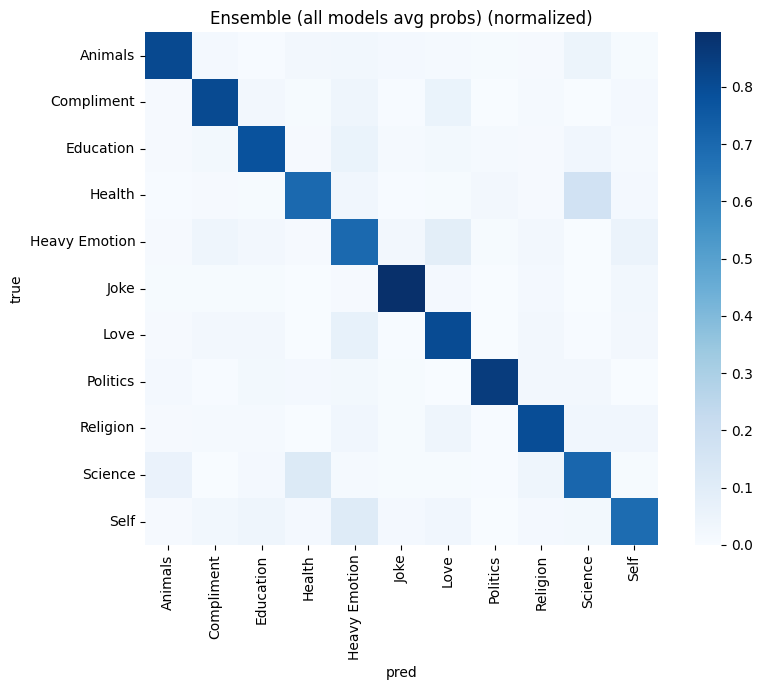

In [ ]:
if CFG.run_ensemble:
    names = list(artifacts.keys())
    y_true = np.asarray(next(iter(artifacts.values()))["test"]["y_true"])

    probs_stack = np.stack([np.asarray(artifacts[n]["test"]["y_prob"]) for n in names], axis=0)
    ens_prob = probs_stack.mean(axis=0)
    ens_pred = ens_prob.argmax(axis=1)

    ensemble_metrics = compute_extended_metrics(y_true, ens_pred)
    print("Ensemble(all models, avg probs):", ensemble_metrics)

    plot_confusion(y_true, ens_pred, id2label, "Ensemble (all models avg probs)")


<!-- report-comment:ensemble -->

#### Phân tích Cell: Ensemble
- Chức năng cell: Kết hợp xác suất của toàn bộ mô hình để kiểm tra lợi ích phối hợp.
- Output chính: Ensemble đạt `accuracy = 0.7718`, `macro_f1 = 0.7760`.
- Nhận xét từ output: Ensemble cải thiện so với đa số model đơn, nhưng vẫn thấp hơn BERT-base (`macro_f1 = 0.7829`). Lợi ích có nhưng chưa đủ để vượt model mạnh nhất.


In [ ]:
# --- So sánh thêm các metric (precision/recall/F1 theo macro & weighted) ---
from sklearn.metrics import precision_score, recall_score

def compute_additional_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    base = compute_metrics(y_true, y_pred)  # accuracy, macro_f1, micro_f1

    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

    weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    # Best/Worst class theo per-class F1
    f1_pc = f1_score(y_true, y_pred, average=None, zero_division=0)
    best_i = int(np.argmax(f1_pc))
    worst_i = int(np.argmin(f1_pc))

    return {
        **base,
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
        "best_class_f1": float(f1_pc[best_i]),
        "worst_class_f1": float(f1_pc[worst_i]),
        "best_class": id2label[best_i],
        "worst_class": id2label[worst_i],
    }

# Lấy dữ liệu trực tiếp từ artifacts để tránh lỗi NameError
rows = []
for name, art in artifacts.items():
    yt = art["test"]["y_true"]
    yp = art["test"]["y_pred"]
    metrics_row = compute_additional_metrics(yt, yp)
    rows.append({"model": name, **metrics_row})

more_results = pd.DataFrame(rows).set_index("model")
more_results = more_results.sort_values("macro_f1", ascending=False)

display(more_results)

print("\nTop models by weighted_f1:")
display(more_results[["weighted_f1", "macro_f1", "accuracy"]].head(6))

,accuracy,macro_f1,micro_f1,macro_precision,macro_recall,weighted_precision,weighted_recall,weighted_f1,best_class_f1,worst_class_f1,best_class,worst_class
model,,,,,,,,,,,,
bert_base,0.776396,0.782943,0.776396,0.794028,0.777412,0.784232,0.776396,0.777559,0.903670,0.673392,Politics,Heavy Emotion
distilbert_layerwise_lr,0.766826,0.771604,0.766826,0.777619,0.771456,0.773340,0.766826,0.767224,0.881633,0.683036,Joke,Science
distilbert,0.761085,0.766328,0.761085,0.775806,0.764085,0.769375,0.761085,0.761705,0.884876,0.653659,Politics,Heavy Emotion
tfidf_svm,0.675598,0.682553,0.675598,0.689130,0.678685,0.682639,0.675598,0.677751,0.830986,0.586207,Politics,Science
distilbert_freeze_backbone,0.670175,0.676911,0.670175,0.682272,0.674608,0.673258,0.670175,0.670307,0.806306,0.552167,Politics,Self
bigru,0.649442,0.654003,0.649442,0.657264,0.653992,0.655993,0.649442,0.651006,0.776699,0.517375,Joke,Science
bilstm,0.647528,0.652775,0.647528,0.660756,0.649246,0.656595,0.647528,0.649628,0.806723,0.534737,Joke,Science



Top models by weighted_f1:


,weighted_f1,macro_f1,accuracy
model,,,
bert_base,0.777559,0.782943,0.776396
distilbert_layerwise_lr,0.767224,0.771604,0.766826
distilbert,0.761705,0.766328,0.761085
tfidf_svm,0.677751,0.682553,0.675598
distilbert_freeze_backbone,0.670307,0.676911,0.670175
bigru,0.651006,0.654003,0.649442


<!-- report-comment:extended_metrics -->

#### Phân tích Cell: Extended Metrics theo lớp
- Chức năng cell: Bổ sung macro/weighted precision-recall-F1 và chỉ ra lớp tốt nhất/kém nhất theo từng mô hình.
- Output chính: BERT-base đứng đầu đồng thời ở nhiều chỉ số; ví dụ `weighted_f1 = 0.7776`. Một số lớp khó lặp lại ở nhiều mô hình như `Heavy Emotion` hoặc `Science`.
- Nhận xét từ output: Cell này giúp giải thích vì sao cùng một accuracy nhưng chất lượng giữa các lớp vẫn khác nhau, rất quan trọng cho phần discussion học thuật.


,Model,Accuracy,Macro-F1,Weighted-F1,Params (M),Latency (ms/sample),Throughput (samples/s)
0,BERT-base,0.7764,0.7829,0.7776,NaN,NaN,NaN
1,distilbert_layerwise_lr,0.7668,0.7716,0.7672,66.9619,4.9943,200.2299
2,DistilBERT,0.7611,0.7663,0.7617,NaN,NaN,NaN
3,tfidf_svm,0.6756,0.6826,0.6778,0.9053,12.1429,82.3525
4,distilbert_freeze_backbone,0.6702,0.6769,0.6703,66.9619,5.3275,187.7046
5,BiGRU,0.6494,0.6540,0.6510,NaN,NaN,NaN
6,BiLSTM,0.6475,0.6528,0.6496,NaN,NaN,NaN


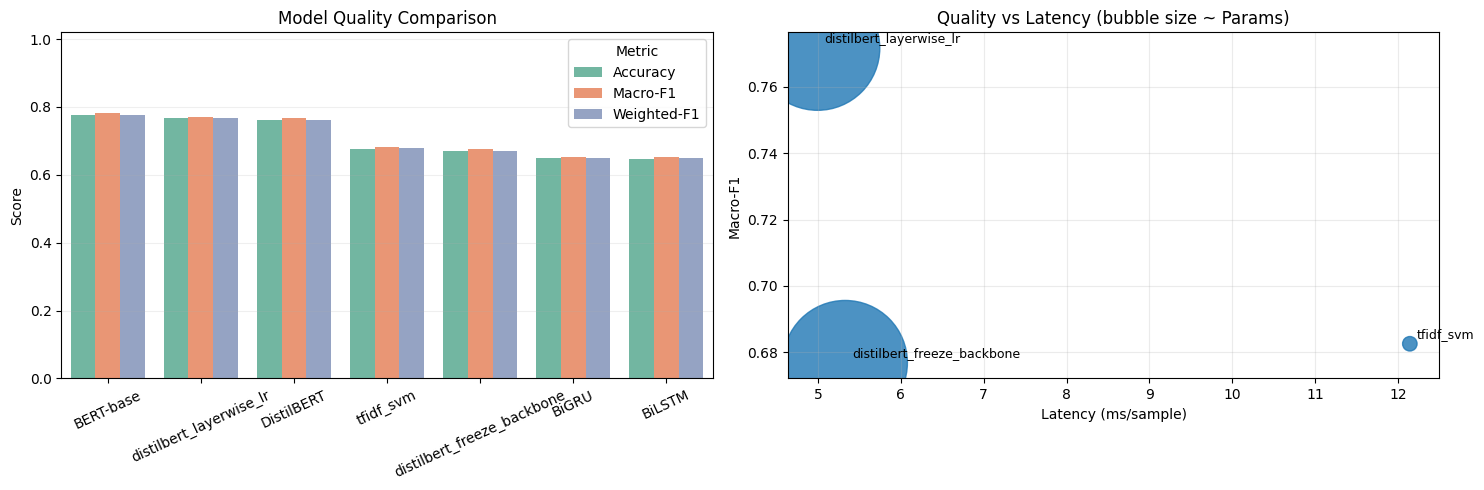

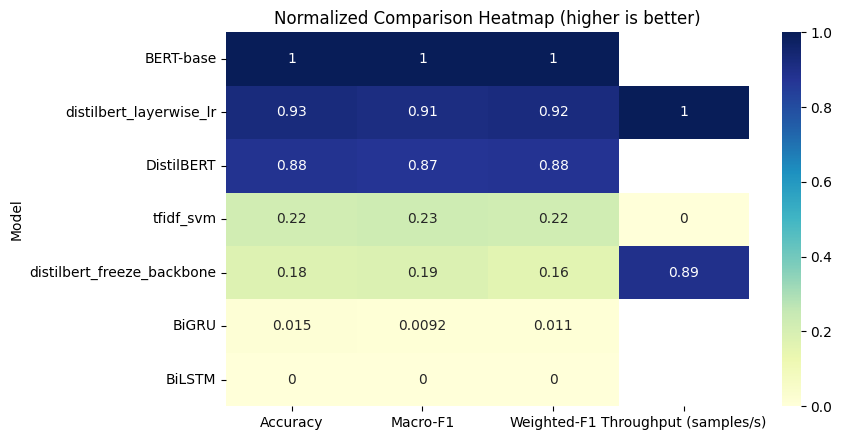

In [ ]:
# --- Visual model comparison (reference-style) ---

# 1) Chuẩn hóa tên model để gộp bảng quality + efficiency
model_label_map = {
    "tfidf_logreg": "TF-IDF+LogReg",
    "bilstm": "BiLSTM",
    "bigru": "BiGRU",
    "custom_transformer": "CustomTransformer",
    "bert_base": "BERT-base",
    "distilbert": "DistilBERT",
}

# Sửa lỗi NameError: sử dụng results_df thay vì results
if "more_results" in globals():
    quality_df = more_results.copy()
elif "results_df" in globals():
    quality_df = results_df.copy()
else:
    # Fallback nếu chưa chạy các cell đánh giá
    rows = []
    for name, art in artifacts.items():
        rows.append({"model": name, **art["test"]["metrics"]})
    quality_df = pd.DataFrame(rows).set_index("model")

if "weighted_f1" not in quality_df.columns:
    quality_df["weighted_f1"] = np.nan

quality_df = quality_df.reset_index().rename(columns={"index": "model"})
quality_df["model_display"] = quality_df["model"].map(model_label_map).fillna(quality_df["model"])

# 2) Ghép thêm thông tin efficiency (latency + params) nếu đã có
viz_df = quality_df.copy()

# Sử dụng biến efficiency_df đã được định nghĩa ở cell RYgg10zLE8JS
if "efficiency_df" in globals():
    eff_df = efficiency_df.copy()
    eff_df["model_display"] = eff_df["model"]
    viz_df = viz_df.merge(
        eff_df[["model_display", "params", "lat_ms_per_sample"]],
        on="model_display",
        how="left",
    )

viz_df["params_m"] = viz_df.get("params", pd.Series(np.nan, index=viz_df.index)) / 1e6
viz_df["throughput_samples_s"] = 1000.0 / viz_df.get("lat_ms_per_sample", pd.Series(np.nan, index=viz_df.index))

# 3) Bảng so sánh tổng hợp
compare_viz_df = viz_df[[
    "model_display",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "params_m",
    "lat_ms_per_sample",
    "throughput_samples_s",
]].copy()

compare_viz_df = compare_viz_df.sort_values("macro_f1", ascending=False)
compare_viz_df = compare_viz_df.rename(columns={
    "model_display": "Model",
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
    "weighted_f1": "Weighted-F1",
    "params_m": "Params (M)",
    "lat_ms_per_sample": "Latency (ms/sample)",
    "throughput_samples_s": "Throughput (samples/s)",
})

num_cols = ["Accuracy", "Macro-F1", "Weighted-F1", "Params (M)", "Latency (ms/sample)", "Throughput (samples/s)"]
for col in num_cols:
    if col in compare_viz_df.columns:
        compare_viz_df[col] = compare_viz_df[col].astype(float).round(4)

display(compare_viz_df)

# 4) Biểu đồ quality (bar) + trade-off quality/latency (scatter)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_quality = compare_viz_df[["Model", "Accuracy", "Macro-F1", "Weighted-F1"]].melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)
sns.barplot(data=plot_quality, x="Model", y="Score", hue="Metric", ax=axes[0], palette="Set2")
axes[0].set_title("Model Quality Comparison")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.02)
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.2)

if compare_viz_df["Latency (ms/sample)"].notna().any():
    sc = axes[1].scatter(
        compare_viz_df["Latency (ms/sample)"],
        compare_viz_df["Macro-F1"],
        s=(compare_viz_df["Params (M)"].fillna(0.5) * 120).clip(lower=60),
        alpha=0.8,
    )
    for _, r in compare_viz_df.dropna(subset=["Latency (ms/sample)"]).iterrows():
        axes[1].annotate(r["Model"], (r["Latency (ms/sample)"], r["Macro-F1"]), fontsize=9, xytext=(5, 4), textcoords="offset points")

    axes[1].set_title("Quality vs Latency (bubble size ~ Params)")
    axes[1].set_xlabel("Latency (ms/sample)")
    axes[1].set_ylabel("Macro-F1")
    axes[1].grid(alpha=0.25)
else:
    axes[1].axis("off")
    axes[1].text(
        0.5, 0.5,
        "Chưa có dữ liệu Latency.\nHãy chạy phần Efficiency trước để vẽ trade-off.",
        ha="center", va="center", fontsize=11,
    )

plt.tight_layout()
plt.show()

# 5) Heatmap tổng hợp (chuẩn hóa 0-1)
heat_cols = ["Accuracy", "Macro-F1", "Weighted-F1", "Throughput (samples/s)"]
heat_df = compare_viz_df[["Model", *heat_cols]].set_index("Model")
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min() + 1e-12)

plt.figure(figsize=(9, 4.5))
sns.heatmap(heat_norm, annot=True, cmap="YlGnBu", cbar=True, vmin=0.0, vmax=1.0)
plt.title("Normalized Comparison Heatmap (higher is better)")
plt.tight_layout()
plt.show()

<!-- report-comment:visual_compare -->

#### Phân tích Cell: Visual Comparison tổng hợp
- Chức năng cell: Trực quan hóa bảng chất lượng + hiệu năng bằng bar/scatter/heatmap.
- Output chính: Bảng xếp hạng xác nhận BERT-base dẫn đầu chất lượng; DistilBERT layerwise đứng thứ hai với latency tốt hơn.
- Nhận xét từ output: Trực quan hóa giúp kết luận rõ ràng hơn cho báo cáo. Một số ô `NaN` (params/latency) cho thấy mapping tên model giữa bảng quality và efficiency chưa hoàn toàn đồng nhất, cần chuẩn hóa để bảng cuối đầy đủ hơn.


###Lưu model Artifacts

In [ ]:
# Metrics summary
metrics_out = {name: art["test"]["metrics"] for name, art in artifacts.items()}
metrics_path = os.path.join(CFG.artifact_dir, "metrics_clean.json")
with open(metrics_path, "w") as f:
    json.dump({"config": asdict(CFG), "metrics": metrics_out}, f, indent=2)
print("saved:", metrics_path)

# Save model bundles
model_dir = CFG.artifact_dir
os.makedirs(model_dir, exist_ok=True)

# baseline
baseline_bundle_path = os.path.join(model_dir, "tfidf_svm_bundle.pkl")
try:
    import joblib
    joblib.dump({
        "vectorizer": artifacts["tfidf_svm"]["vectorizer"],
        "model": artifacts["tfidf_svm"]["model"],
        "label2id": label2id,
        "id2label": id2label,
    }, baseline_bundle_path)
    print("saved:", baseline_bundle_path)
except Exception as e:
    print("skip baseline pickle (joblib unavailable):", e)

# torch bundles (dynamic over all artifacts, including fine-tune strategy runs)
for name, art in artifacts.items():
    if art["family"] not in {"word_torch", "hf_torch"}:
        continue

    out = {
        "name": name,
        "family": art["family"],
        "state_dict": {k: v.detach().cpu() for k, v in art["model"].state_dict().items()},
        "label2id": label2id,
        "id2label": id2label,
        "max_len": CFG.max_len,
    }
    if art["family"] == "word_torch":
        out["vocab"] = art["vocab"]
        out["use_lengths"] = art["use_lengths"]
    if art["family"] == "hf_torch":
        out["model_name"] = art["model_name"]
    if "strategy" in art:
        out["strategy"] = art["strategy"]

    path = os.path.join(model_dir, f"{name}_clean.pt")
    torch.save(out, path)
    print("saved:", path)


saved: /content/drive/MyDrive/deep_learning/artifacts/metrics_clean.json
saved: /content/drive/MyDrive/deep_learning/artifacts/tfidf_svm_bundle.pkl
saved: /content/drive/MyDrive/deep_learning/artifacts/bilstm_clean.pt
saved: /content/drive/MyDrive/deep_learning/artifacts/bigru_clean.pt
saved: /content/drive/MyDrive/deep_learning/artifacts/bert_base_clean.pt
saved: /content/drive/MyDrive/deep_learning/artifacts/distilbert_clean.pt
saved: /content/drive/MyDrive/deep_learning/artifacts/distilbert_freeze_backbone_clean.pt
saved: /content/drive/MyDrive/deep_learning/artifacts/distilbert_layerwise_lr_clean.pt


<!-- report-comment:save_artifacts -->

#### Phân tích Cell: Lưu artifacts và metrics
- Chức năng cell: Lưu checkpoint, tokenizer metadata và file tổng hợp metrics để tái sử dụng.
- Output chính: Đã lưu `metrics_clean.json` vào thư mục artifacts.
- Nhận xét từ output: Đây là bước quan trọng để bảo đảm tính tái lập của bài tập lớn và phục vụ demo/inference mà không cần train lại.


###Kết luận ngắn

- Kết quả thực nghiệm nhất quán: **BERT-base** là mốc chất lượng tốt nhất.
- Nếu ưu tiên cân bằng chất lượng-tốc độ, **DistilBERT + layerwise LR decay** là lựa chọn thực dụng.
- Với yêu cầu realtime cao, BiGRU/BiLSTM có lợi thế latency nhưng cần thêm kỹ thuật regularization/augmentation để thu hẹp khoảng cách chất lượng.
- Các phân tích calibration, robustness và interpretability bổ sung tốt cho phần đánh giá định lượng, giúp báo cáo thuyết phục hơn.


###Demo

In [ ]:
import os
import re
import math
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gradio as gr

from transformers import AutoTokenizer, AutoModelForSequenceClassification

ARTIFACT_DIR = "/content/drive/MyDrive/deep_learning/artifacts"
SHARED_TOKENIZER_NAME = "bert-base-uncased"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

SHARED_BERT_TOKENIZER = AutoTokenizer.from_pretrained(SHARED_TOKENIZER_NAME, use_fast=True)
PAD_TOKEN = SHARED_BERT_TOKENIZER.pad_token or "[PAD]"
UNK_TOKEN = SHARED_BERT_TOKENIZER.unk_token or "[UNK]"
PAD_ID = int(SHARED_BERT_TOKENIZER.pad_token_id if SHARED_BERT_TOKENIZER.pad_token_id is not None else 0)
UNK_ID = int(SHARED_BERT_TOKENIZER.unk_token_id if SHARED_BERT_TOKENIZER.unk_token_id is not None else 100)

print("shared_tokenizer:", SHARED_TOKENIZER_NAME)
print("pad_token/pad_id:", PAD_TOKEN, PAD_ID)
print("unk_token/unk_id:", UNK_TOKEN, UNK_ID)


def simple_tokenize(text: str) -> List[str]:
    return SHARED_BERT_TOKENIZER.tokenize(str(text))


def bert_pretokenize_text(text: str) -> str:
    return " ".join(simple_tokenize(text))


def get_pad_id(vocab: Dict[str, int]) -> int:
    for tok in [PAD_TOKEN, "[PAD]", "<pad>"]:
        if tok in vocab:
            return int(vocab[tok])
    return PAD_ID


def get_unk_id(vocab: Dict[str, int]) -> int:
    for tok in [UNK_TOKEN, "[UNK]", "<unk>"]:
        if tok in vocab:
            return int(vocab[tok])
    return UNK_ID


def numericalize(tokens: List[str], vocab: Dict[str, int]) -> List[int]:
    ids = SHARED_BERT_TOKENIZER.convert_tokens_to_ids(tokens)
    unk = get_unk_id(vocab)
    return [int(i if i is not None else unk) for i in ids]


def make_padding_mask(input_ids: torch.Tensor, pad_id: int = 0) -> torch.Tensor:
    return input_ids.eq(pad_id)


device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


shared_tokenizer: bert-base-uncased
pad_token/pad_id: [PAD] 0
unk_token/unk_id: [UNK] 100


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, emb_dim: int = 200, hidden_dim: int = 256, num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = self.dropout(torch.cat([fw, bw], dim=1))
        return self.fc(h)


class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, emb_dim: int = 200, hidden_dim: int = 256, num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.gru(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = self.dropout(torch.cat([fw, bw], dim=1))
        return self.fc(h)


class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size: int, num_labels: int, d_model: int = 256, nhead: int = 8, num_layers: int = 4, dim_feedforward: int = 1024, dropout: float = 0.1, max_len: int = 512, pad_id: int = 0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.max_len = max_len
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb = nn.Embedding(max_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers, enable_nested_tensor=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_labels)

    def forward(self, input_ids: torch.Tensor):
        bsz, seqlen = input_ids.shape
        seqlen = min(seqlen, self.max_len)
        input_ids = input_ids[:, :seqlen]

        pos = torch.arange(seqlen, device=input_ids.device).unsqueeze(0).expand(bsz, seqlen)
        x = self.tok_emb(input_ids) * (self.d_model ** 0.5)
        x = x + self.pos_emb(pos)

        pad_mask = make_padding_mask(input_ids, self.pad_id)
        h = self.encoder(x, src_key_padding_mask=pad_mask)

        nonpad = (~pad_mask).float()
        denom = nonpad.sum(dim=1, keepdim=True).clamp(min=1.0)
        pooled = (h * nonpad.unsqueeze(-1)).sum(dim=1) / denom
        return self.fc(self.dropout(pooled))


In [ ]:
def _normalize_id2label(id2label: Dict) -> Dict[int, str]:
    out = {}
    for k, v in id2label.items():
        out[int(k)] = str(v)
    return out


def _normalize_label2id(label2id: Dict) -> Dict[str, int]:
    out = {}
    for k, v in label2id.items():
        out[str(k)] = int(v)
    return out


def _infer_num_layers_from_keys(keys: List[str], prefix: str) -> int:
    idx = []
    patt = re.compile(prefix)
    for k in keys:
        m = patt.search(k)
        if m is not None:
            idx.append(int(m.group(1)))
    return (max(idx) + 1) if idx else 1


def infer_bilstm_kwargs(state_dict: Dict[str, torch.Tensor]) -> Dict[str, int]:
    vocab_size, emb_dim = state_dict["embedding.weight"].shape
    num_labels = state_dict["fc.weight"].shape[0]
    hidden_dim = state_dict["fc.weight"].shape[1] // 2
    num_layers = _infer_num_layers_from_keys(list(state_dict.keys()), r"lstm\.weight_ih_l(\d+)$")
    return {
        "vocab_size": int(vocab_size),
        "num_labels": int(num_labels),
        "emb_dim": int(emb_dim),
        "hidden_dim": int(hidden_dim),
        "num_layers": int(num_layers),
    }


def infer_bigru_kwargs(state_dict: Dict[str, torch.Tensor]) -> Dict[str, int]:
    vocab_size, emb_dim = state_dict["embedding.weight"].shape
    num_labels = state_dict["fc.weight"].shape[0]
    hidden_dim = state_dict["fc.weight"].shape[1] // 2
    num_layers = _infer_num_layers_from_keys(list(state_dict.keys()), r"gru\.weight_ih_l(\d+)$")
    return {
        "vocab_size": int(vocab_size),
        "num_labels": int(num_labels),
        "emb_dim": int(emb_dim),
        "hidden_dim": int(hidden_dim),
        "num_layers": int(num_layers),
    }


def infer_transformer_kwargs(state_dict: Dict[str, torch.Tensor], pad_id: int = 0) -> Dict[str, int]:
    vocab_size, d_model = state_dict["tok_emb.weight"].shape
    num_labels = state_dict["fc.weight"].shape[0]
    max_len = state_dict["pos_emb.weight"].shape[0]
    dim_feedforward = state_dict["encoder.layers.0.linear1.weight"].shape[0]
    num_layers = _infer_num_layers_from_keys(list(state_dict.keys()), r"encoder\.layers\.(\d+)\.")

    nhead = 1
    for cand in [16, 8, 4, 2, 1]:
        if d_model % cand == 0:
            nhead = cand
            break

    return {
        "vocab_size": int(vocab_size),
        "num_labels": int(num_labels),
        "d_model": int(d_model),
        "nhead": int(nhead),
        "num_layers": int(num_layers),
        "dim_feedforward": int(dim_feedforward),
        "max_len": int(max_len),
        "pad_id": int(pad_id),
    }


def load_all_artifacts(artifact_dir: str = ARTIFACT_DIR):
    artifacts: Dict[str, dict] = {}
    label2id: Optional[Dict[str, int]] = None
    id2label: Optional[Dict[int, str]] = None

    baseline_path = os.path.join(artifact_dir, "tfidf_svm_bundle.pkl")
    if os.path.exists(baseline_path):
        bundle = joblib.load(baseline_path)
        label2id = _normalize_label2id(bundle["label2id"])
        id2label = _normalize_id2label(bundle["id2label"])
        artifacts["tfidf_svm"] = {
            "name": "tfidf_svm",
            "family": "sklearn",
            "vectorizer": bundle["vectorizer"],
            "model": bundle["model"],
        }
    else:
        print(f"[warn] missing baseline bundle: {baseline_path}")

    for name in ["bilstm", "bigru", "bert_base", "distilbert","distilbert_freeze_backbone","distilbert_layerwise_lr"]:
        ckpt_path = os.path.join(artifact_dir, f"{name}_clean.pt")
        if not os.path.exists(ckpt_path):
            print(f"[warn] missing checkpoint: {ckpt_path}")
            continue

        ckpt = torch.load(ckpt_path, map_location=DEVICE)

        local_label2id = _normalize_label2id(ckpt["label2id"])
        local_id2label = _normalize_id2label(ckpt["id2label"])
        if label2id is None:
            label2id = local_label2id
            id2label = local_id2label

        family = ckpt.get("family")
        if family == "word_torch":
            vocab = ckpt["vocab"]
            pad_id = get_pad_id(vocab)
            state = ckpt["state_dict"]

            if name == "bilstm":
                kwargs = infer_bilstm_kwargs(state)
                model = BiLSTMClassifier(**kwargs)
            elif name == "bigru":
                kwargs = infer_bigru_kwargs(state)
                model = BiGRUClassifier(**kwargs)
            # elif name == "custom_transformer":
            #     kwargs = infer_transformer_kwargs(state, pad_id=pad_id)
            #     model = TransformerEncoderClassifier(**kwargs)
            else:
                print(f"[warn] unknown word model name: {name}")
                continue

            model.load_state_dict(state, strict=True)
            model.to(DEVICE).eval()

            artifacts[name] = {
                "name": name,
                "family": "word_torch",
                "model": model,
                "vocab": vocab,
                "use_lengths": bool(ckpt.get("use_lengths", True)),
                "max_len": int(ckpt.get("max_len", 256)),
            }
            continue

        if family == "hf_torch":
            model_name = ckpt["model_name"]
            model = AutoModelForSequenceClassification.from_pretrained(
                model_name,
                num_labels=len(local_label2id),
                id2label=local_id2label,
                label2id=local_label2id,
            ).to(DEVICE)
            model.load_state_dict(ckpt["state_dict"], strict=True)
            model.eval()
            tokenizer = AutoTokenizer.from_pretrained(model_name)

            artifacts[name] = {
                "name": name,
                "family": "hf_torch",
                "model": model,
                "tokenizer": tokenizer,
                "model_name": model_name,
                "max_len": int(ckpt.get("max_len", 256)),
            }
            continue

        print(f"[warn] unknown family for {name}: {family}")

    if label2id is None or id2label is None:
        raise RuntimeError("Could not load label mappings from saved artifacts.")

    return artifacts, label2id, id2label


artifacts, label2id, id2label = load_all_artifacts(ARTIFACT_DIR)
print("loaded models:", list(artifacts.keys()))
print("num_labels:", len(label2id))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


loaded models: ['tfidf_svm', 'bilstm', 'bigru', 'bert_base', 'distilbert', 'distilbert_freeze_backbone', 'distilbert_layerwise_lr']
num_labels: 11


<!-- report-comment:demo_load -->

#### Phân tích Cell: Nạp lại mô hình cho Demo
- Chức năng cell: Load toàn bộ artifact đã huấn luyện để phục vụ suy luận tương tác.
- Output chính: Các checkpoint được nạp thành công, có log load report cho model Transformer.
- Nhận xét từ output: Pipeline inference đã tách rời khỏi huấn luyện, đúng chuẩn triển khai end-to-end cho sản phẩm demo.


In [ ]:
def _batch_ids_from_texts(texts: List[str], vocab: Dict[str, int], max_len: int, pad_id: int):
    seqs = []
    lengths = []
    unk_id = get_unk_id(vocab)
    for t in texts:
        ids = numericalize(simple_tokenize(t), vocab)[:max_len]
        if len(ids) == 0:
            ids = [unk_id]
        seqs.append(ids)
        lengths.append(len(ids))

    max_batch = min(max(lengths), max_len)
    arr = torch.full((len(seqs), max_batch), fill_value=pad_id, dtype=torch.long)
    for i, ids in enumerate(seqs):
        ids = ids[:max_batch]
        arr[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)

    return arr, torch.tensor(lengths, dtype=torch.long).clamp(max=max_len)


def predict_proba_baseline(artifact: dict, texts: List[str]) -> np.ndarray:
    x_texts = [bert_pretokenize_text(t) for t in texts]
    x = artifact["vectorizer"].transform(x_texts)
    return artifact["model"].predict_proba(x)


def predict_proba_word(artifact: dict, texts: List[str], batch_size: int = 64) -> np.ndarray:
    model = artifact["model"]
    model.eval()
    vocab = artifact["vocab"]
    use_lengths = artifact["use_lengths"]
    max_len = int(artifact.get("max_len", 256))
    pad_id = get_pad_id(vocab)

    probs_all = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            input_ids, lengths = _batch_ids_from_texts(batch, vocab, max_len, pad_id)
            input_ids = input_ids.to(DEVICE)
            lengths = lengths.to(DEVICE)
            logits = model(input_ids, lengths) if use_lengths else model(input_ids)
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            probs_all.append(probs)

    return np.vstack(probs_all) if probs_all else np.zeros((0, len(label2id)))


def predict_proba_hf(artifact: dict, texts: List[str], batch_size: int = 32) -> np.ndarray:
    model = artifact["model"]
    tokenizer = artifact["tokenizer"]
    max_len = int(artifact.get("max_len", 256))
    model.eval()

    probs_all = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            enc = tokenizer(batch, truncation=True, max_length=max_len, padding=True, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            probs_all.append(probs)

    return np.vstack(probs_all) if probs_all else np.zeros((0, len(label2id)))


def predict_proba_any(name: str, texts: List[str]) -> np.ndarray:
    art = artifacts[name]
    if art["family"] == "sklearn":
        return predict_proba_baseline(art, texts)
    if art["family"] == "word_torch":
        return predict_proba_word(art, texts)
    if art["family"] == "hf_torch":
        return predict_proba_hf(art, texts)
    raise ValueError(f"Unknown family: {art['family']}")


def _word_forward_with_embeds(model, embeds: torch.Tensor, lengths: torch.Tensor, input_ids: torch.Tensor, use_lengths: bool):
    if use_lengths and isinstance(model, BiLSTMClassifier):
        packed = nn.utils.rnn.pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = model.lstm(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = model.dropout(torch.cat([fw, bw], dim=1))
        return model.fc(h)

    if use_lengths and isinstance(model, BiGRUClassifier):
        packed = nn.utils.rnn.pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = model.gru(packed)
        fw, bw = h_n[-2], h_n[-1]
        h = model.dropout(torch.cat([fw, bw], dim=1))
        return model.fc(h)

    if isinstance(model, TransformerEncoderClassifier):
        bsz, seqlen = input_ids.shape
        seqlen = min(seqlen, model.max_len)
        input_ids = input_ids[:, :seqlen]
        embeds = embeds[:, :seqlen, :]

        pos = torch.arange(seqlen, device=input_ids.device).unsqueeze(0).expand(bsz, seqlen)
        x = embeds * (model.d_model ** 0.5)
        x = x + model.pos_emb(pos)

        pad_mask = make_padding_mask(input_ids, pad_id=model.pad_id)
        h = model.encoder(x, src_key_padding_mask=pad_mask)

        nonpad = (~pad_mask).float()
        denom = nonpad.sum(dim=1, keepdim=True).clamp(min=1.0)
        pooled = (h * nonpad.unsqueeze(-1)).sum(dim=1) / denom
        return model.fc(model.dropout(pooled))

    raise ValueError(f"Unsupported word model type: {type(model)}")


def sklearn_local_tfidf_importance(artifact: dict, text: str, top_k: int = 25):
    vec = artifact["vectorizer"]
    model = artifact["model"]

    x_text = bert_pretokenize_text(text)
    x = vec.transform([x_text])
    probs = model.predict_proba(x)[0]
    pred = int(np.argmax(probs))

    row = x[0].tocoo()
    if row.nnz == 0:
        return pred, float(probs[pred]), pd.DataFrame(columns=["token", "score"])

    feature_names = np.asarray(vec.get_feature_names_out())
    order = np.argsort(row.data)[::-1][:top_k]
    tok = feature_names[row.col[order]]
    val = row.data[order]
    return pred, float(probs[pred]), pd.DataFrame({"token": tok, "score": val})


def word_model_saliency_from_artifact(artifact: dict, text: str, target_label: Optional[int] = None):
    model = artifact["model"]
    vocab = artifact["vocab"]
    use_lengths = artifact["use_lengths"]
    max_len = int(artifact.get("max_len", 256))

    was_training = model.training
    model.eval()

    try:
        tokens = simple_tokenize(text)[:max_len]
        if len(tokens) == 0:
            tokens = [UNK_TOKEN]

        ids = numericalize(tokens, vocab)
        if len(ids) == 0:
            ids = [get_unk_id(vocab)]
        input_ids = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
        lengths = torch.tensor([len(ids)], dtype=torch.long, device=DEVICE)

        emb_layer = model.embedding if hasattr(model, "embedding") else model.tok_emb
        embeds = emb_layer(input_ids)
        embeds.retain_grad()

        use_cudnn_fallback = DEVICE.type == "cuda" and isinstance(model, (BiLSTMClassifier, BiGRUClassifier))
        if use_cudnn_fallback:
            with torch.backends.cudnn.flags(enabled=False):
                logits = _word_forward_with_embeds(model, embeds, lengths, input_ids, use_lengths)
        else:
            logits = _word_forward_with_embeds(model, embeds, lengths, input_ids, use_lengths)

        if target_label is None:
            target_label = int(logits.argmax(dim=-1).item())

        score = logits[0, target_label]
        model.zero_grad(set_to_none=True)
        score.backward()

        grads = embeds.grad.detach()
        sal = grads.norm(dim=-1).squeeze(0)
        sal = sal / (sal.max().clamp(min=1e-12))
        return tokens, sal.detach().cpu().numpy(), target_label
    finally:
        model.train(was_training)


def hf_model_saliency_from_artifact(artifact: dict, text: str, target_label: Optional[int] = None):
    model = artifact["model"]
    tokenizer = artifact["tokenizer"]
    max_len = int(artifact.get("max_len", 256))

    was_training = model.training
    model.eval()

    try:
        enc = tokenizer(text, truncation=True, max_length=max_len, return_tensors="pt")
        input_ids = enc["input_ids"].to(DEVICE)
        attn_mask = enc["attention_mask"].to(DEVICE)

        emb_layer = model.get_input_embeddings()
        inputs_embeds = emb_layer(input_ids)
        inputs_embeds.retain_grad()

        out = model(inputs_embeds=inputs_embeds, attention_mask=attn_mask)
        logits = out.logits

        if target_label is None:
            target_label = int(logits.argmax(dim=-1).item())

        score = logits[0, target_label]
        model.zero_grad(set_to_none=True)
        score.backward()

        grads = inputs_embeds.grad.detach()
        sal = grads.norm(dim=-1).squeeze(0)
        sal = sal * attn_mask.squeeze(0)
        sal = sal / (sal.max().clamp(min=1e-12))

        tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
        return tokens, sal.detach().cpu().numpy(), target_label
    finally:
        model.train(was_training)


def _prepare_tokens_for_plot(tokens, scores, top_k: int = 20):
    tokens = list(tokens)
    scores = np.asarray(scores, dtype=np.float32)
    if len(tokens) == 0 or len(scores) == 0:
        return [], np.array([])

    n = min(len(tokens), len(scores))
    tokens = tokens[:n]
    scores = scores[:n]

    special = {"[CLS]", "[SEP]", "[PAD]", "<s>", "</s>", "<pad>"}
    keep = [i for i, tok in enumerate(tokens) if tok not in special]
    if len(keep) > 0:
        tokens = [tokens[i] for i in keep]
        scores = scores[keep]

    merged_tokens, merged_scores = [], []
    for tok, sc in zip(tokens, scores):
        if tok.startswith("##") and len(merged_tokens) > 0:
            merged_tokens[-1] = merged_tokens[-1] + tok[2:]
            merged_scores[-1] = max(merged_scores[-1], float(sc))
        else:
            merged_tokens.append(tok)
            merged_scores.append(float(sc))

    if len(merged_tokens) == 0:
        return [], np.array([])

    scores = np.asarray(merged_scores, dtype=np.float32)
    k = min(top_k, len(merged_tokens))
    top_idx = np.argsort(-scores)[:k]
    return [merged_tokens[i] for i in top_idx], scores[top_idx]


def make_token_plot(tokens, scores, title: str):
    fig, ax = plt.subplots(figsize=(max(10, len(tokens) * 0.35), 3.5))
    sns.barplot(x=tokens, y=scores, color="#4C72B0", ax=ax)
    ax.set_title(title)
    ax.set_ylabel("score")
    ax.tick_params(axis="x", rotation=60)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    fig.tight_layout()
    return fig


def _topk_rows(name: str, probs: np.ndarray, top_k_pred: int):
    idx = np.argsort(-probs)[:top_k_pred]
    rows = []
    for rank, i in enumerate(idx, start=1):
        rows.append({
            "model": name,
            "rank": rank,
            "label": id2label[int(i)],
            "score": float(probs[i]),
        })
    return rows


DEFAULT_TOPK_PRED = 3
DEFAULT_TOPK_TOKENS = 20


def _empty_outputs(message: str):
    return pd.DataFrame(), None, pd.DataFrame(columns=["token", "score"]), message


def _interpret_single_model(model_name: str, text: str, probs: Optional[np.ndarray] = None):
    if model_name not in artifacts:
        return None, pd.DataFrame(columns=["token", "score"]), f"Model not found: {model_name}"

    art = artifacts[model_name]
    if probs is None:
        probs = predict_proba_any(model_name, [text])[0]

    if art["family"] == "sklearn":
        pred, conf, imp_df = sklearn_local_tfidf_importance(art, text, top_k=DEFAULT_TOPK_TOKENS)
        imp_df = imp_df[["token", "score"]].copy() if len(imp_df) > 0 else pd.DataFrame(columns=["token", "score"])
        fig = make_token_plot(imp_df["token"].tolist(), imp_df["score"].to_numpy(), f"{model_name} TF-IDF token importance") if len(imp_df) > 0 else None
        return fig, imp_df, f"Interpretability model: {model_name} | Predicted: {id2label[pred]} | confidence={conf:.4f}"

    if art["family"] == "word_torch":
        tokens, saliency, pred = word_model_saliency_from_artifact(art, text)
        plot_tokens, plot_scores = _prepare_tokens_for_plot(tokens, saliency, top_k=DEFAULT_TOPK_TOKENS)
        imp_df = pd.DataFrame({"token": plot_tokens, "score": plot_scores})
        fig = make_token_plot(plot_tokens, plot_scores, f"{model_name} gradient saliency") if len(imp_df) > 0 else None
        return fig, imp_df, f"Interpretability model: {model_name} | Predicted: {id2label[pred]} | confidence={float(probs[pred]):.4f}"

    if art["family"] == "hf_torch":
        tokens, saliency, pred = hf_model_saliency_from_artifact(art, text)
        plot_tokens, plot_scores = _prepare_tokens_for_plot(tokens, saliency, top_k=DEFAULT_TOPK_TOKENS)
        imp_df = pd.DataFrame({"token": plot_tokens, "score": plot_scores})
        fig = make_token_plot(plot_tokens, plot_scores, f"{model_name} gradient saliency") if len(imp_df) > 0 else None
        return fig, imp_df, f"Interpretability model: {model_name} | Predicted: {id2label[pred]} | confidence={float(probs[pred]):.4f}"

    return None, pd.DataFrame(columns=["token", "score"]), f"Unsupported family: {art['family']}"


def predict_and_interpret(text: str, model_name: str):
    text = str(text).strip()
    if not text:
        return _empty_outputs("Please input non-empty text.")

    if model_name == "all":
        model_probs = {}
        pred_rows = []
        for name in artifacts.keys():
            probs = predict_proba_any(name, [text])[0]
            model_probs[name] = probs
            pred_rows.extend(_topk_rows(name, probs, top_k_pred=DEFAULT_TOPK_PRED))

        pred_df = pd.DataFrame(pred_rows)
        if len(model_probs) == 0:
            return pred_df, None, pd.DataFrame(columns=["token", "score"]), "No models loaded."

        best_model = max(model_probs.keys(), key=lambda n: float(model_probs[n].max()))
        fig, imp_df, interp_msg = _interpret_single_model(best_model, text, probs=model_probs[best_model])
        msg = f"Predictions from all models. {interp_msg}"
        return pred_df, fig, imp_df, msg

    if model_name not in artifacts:
        return _empty_outputs(f"Model not found: {model_name}")

    probs = predict_proba_any(model_name, [text])[0]
    pred_df = pd.DataFrame(_topk_rows(model_name, probs, top_k_pred=DEFAULT_TOPK_PRED))
    fig, imp_df, msg = _interpret_single_model(model_name, text, probs=probs)
    return pred_df, fig, imp_df, msg


In [ ]:
choices = ["all"] + list(artifacts.keys())
default_model = "bert_base" if "bert_base" in artifacts else (choices[1] if len(choices) > 1 else "all")


def _default_examples():
    path = "Context.csv"
    if not os.path.exists(path):
        return [["I love this project and I feel proud.", default_model]]

    df = pd.read_csv(path)
    samples = []
    for _, row in df.head(6).iterrows():
        samples.append([str(row["Text"]), default_model])
    return samples


with gr.Blocks(title="Text Classification + Interpretability") as demo:
    gr.Markdown("## Text Classification Demo\nLoad saved models from artifacts and run predict + interpretability.")

    with gr.Row():
        text_input = gr.Textbox(lines=6, label="Input text")
        with gr.Column():
            model_input = gr.Dropdown(choices=choices, value=default_model, label="Model")
            run_btn = gr.Button("Run")

    pred_out = gr.Dataframe(label="Predictions", wrap=True)
    plot_out = gr.Plot(label="Interpretability plot")
    token_out = gr.Dataframe(label="Token importance", wrap=True)
    msg_out = gr.Textbox(label="Status")

    run_btn.click(
        fn=predict_and_interpret,
        inputs=[text_input, model_input],
        outputs=[pred_out, plot_out, token_out, msg_out],
    )

    gr.Examples(
        examples=_default_examples(),
        inputs=[text_input, model_input],
    )


demo.launch(share=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

<!-- report-comment:demo_launch -->

#### Phân tích Cell: Khởi chạy giao diện Demo
- Chức năng cell: Khởi tạo UI để nhập văn bản và dự đoán bằng một hoặc nhiều mô hình.
- Output chính: Interface khởi chạy thành công trong Colab (xuất hiện object hiển thị).
- Nhận xét từ output: Bước này hoàn tất chu trình bài tập lớn từ EDA đến ứng dụng thực tế; chứng minh mô hình có thể dùng trực tiếp cho suy luận tương tác.
